In [1]:
#!pip install wordcloud
#!pip install spacy
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.3/12.8 MB 10.2 MB/s eta 0:00:02
     -- ------------------------------------- 0.8/12.8 MB 8.6 MB/s eta 0:00:02
     ---- ----------------------------------- 1.5/12.8 MB 11.6 MB/s eta 0:00:01
     ------ --------------------------------- 2.2/12.8 MB 14.1 MB/s eta 0:00:01
     --------- ------------------------------ 3.1/12.8 MB 15.4 MB/s eta 0:00:01
     ------------- -------------------------- 4.3/12.8 MB 17.1 MB/s eta 0:00:01
     ----------------- ---------------------- 5.7/12.8 MB 20.2 MB/s eta 0:00:01
     ---------------------- ----------------- 7.3/12.8 MB 22.1 MB/s eta 0:00:01
     ------------------------- -------------- 8.1/12.8 MB 22.5 MB/s eta 0:00:01
     ---------------------------- ----------- 9.0/12.8 MB 22.2 MB/s eta 0:00:01
     ------------------------------ --------- 9.9/12.8 MB 22.6 MB/s eta 0:00:01
     -------------------------------- ------ 10.8

In [2]:
import numpy as np 
import pandas as pd 
import os 
import re 
import tiktoken
import ast
#Langchain Imports
from langchain.llms import OpenAI
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain
from langchain import FewShotPromptTemplate
from langchain.agents.agent_types import AgentType
from langchain.chat_models import ChatOpenAI
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain.document_loaders import UnstructuredPDFLoader
from langchain.indexes import VectorstoreIndexCreator
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

#NLTK Imports
import nltk 
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import PyPDF2

nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\QuyenN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\QuyenN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
#The total tokens for question + response based on the model. This can change with different models!
max_tokens= 3000
real_max_tokens = 4097 

#We have to anticipate how long answers will be - my expected response is about 250 tokens so I'm being overly careful here:
expected_response_tokens = 1000

#specificy large languate model 
OpenAI_key = "sk-proj-Z3azBQxgMb14LYqqWJeUT3BlbkFJXe04TidhcC9bElNpy5P5"
print(OpenAI_key)
llm=OpenAI(model="gpt-3.5-turbo-instruct",api_key=OpenAI_key)

#folder 
folder = 'C:/Users/QuyenN/Offline work/2. GNS/5-Climate risk disclosure/'

#full answer
full_answers =pd.read_csv(f'{folder}/result/full_answers.final.csv')

#company info 
master_list = pd.read_excel(f'{folder}/result/List of firms with Climate Reports.xlsx', sheet_name  = '2.masterfirm')
master_disclosure =  pd.read_excel(f'{folder}/result/List of firms with Climate Reports.xlsx', sheet_name  = '1.master_list_7May')

sk-proj-Z3azBQxgMb14LYqqWJeUT3BlbkFJXe04TidhcC9bElNpy5P5


C:\Users\QuyenN\AppData\Local\anaconda3\Lib\site-packages\langchain_core\_api\deprecation.py:119: LangChainDeprecationWarning: The class `OpenAI` was deprecated in LangChain 0.0.10 and will be removed in 0.3.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import OpenAI`.
  warn_deprecated(


In [4]:
#A function for counting the tokens in a text, to not exceed max number of tokens. 
def get_token_count(text):
    encoding = tiktoken.get_encoding("cl100k_base")
    return len(encoding.encode(text))

# A function to get page text 
def get_pages_text(file_name):
    pages_text = {}
    with open(file_name, 'rb') as pdfFileObject:
        pdfReader = PyPDF2.PdfReader(pdfFileObject)

        print("No. of Pages:", len(pdfReader.pages))
        for i, page in enumerate(pdfReader.pages):
            pages_text[i] = page.extract_text()
    return pages_text 

# Clean data 
def clean_data(text):
    # change to lower and remove spaces on either side
    text =  text.lower().strip() 

    # remove extra spaces in between
    text = re.sub(' +', ' ', text)

    # remove punctuation
    text= re.sub('[^a-zA-Z]', ' ', text)

    # remove stopwords and get the stem
    text =  ' '.join(st.stem(x) for x in text.split() if x not in stop_words)
    return text

# A function Iterate until token count does not exceed - split pages if needed 
def split_pages_text(pages_text, max_tokens):
    j = 0 
    pages_text_new = dict()
    token_counts = dict()
    token_counts_exceed = dict()
    for i, page in pages_text.items():
        token = get_token_count(page)
        token_exceed = token > max_tokens
        token_counts[i] = token
        token_counts_exceed[i] = token_exceed
        #print(i,token, token_exceed)
        # Divide pages into multiple pages if token count exceeds max_tokens
        if not token_exceed: 
            pages_text_new[j] = page
            j += 1  # Increment j to keep unique keys in pages_text_new
            #print(j)
        else:
            # Calculate number of chunks needed
            number_chunks = token // max_tokens
            if token % max_tokens != 0:
                number_chunks += 1  # Add an extra chunk if there's a remainder
            # Divide the page into chunks
            words = page.split(' ')  # Split page into words
            chunk_size = len(words) // number_chunks  # Number of words per chunk
            for chunk_index in range(number_chunks):
                start_index = chunk_index * chunk_size
                end_index = start_index + chunk_size if chunk_index < number_chunks - 1 else len(words)
                chunk_text = " ".join(words[start_index:end_index])
                pages_text_new[j] = chunk_text
                j += 1  # Increment j to keep unique keys in pages_text_new~~
                #print(j)
    return pages_text_new
            
#A function to calculate token count 
def calculate_token_counts(pages_text,max_tokens):
    token_counts = dict()
    token_counts_exceed = dict()
    for i, page in pages_text.items():
        token = get_token_count(page)
        token_exceed = token > max_tokens
        token_counts[i] = token
        token_counts_exceed[i] = token_exceed
    return token_counts, token_counts_exceed

#A function to calculate cost 
def calculate_token_cost(token_counts_final):
    cost = token_counts_final/1000 *0.005
    return cost 


## CODING ANALYSIS BASED ON NLP

In [5]:
#sentiment
sent = SentimentIntensityAnalyzer()
st = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))


## climate hazard datasets key words
drought = ['drought', 'severe drought', 'dry', 'SPI', 'standardised precipitation index', 'standardized precipitation index', 'rainfall', '10 minute average', 'topography']
winds= ['wind', 'extreme winds', 'cyclone','tsunami']
rainfall =['rain','pluvial','pluvial flooding','rainfall']
river = ['river','flood', 'river flooding', 'fluvial',
         'daily rainfall', 'river level', 'flow', 'soils', 'vegetation', 
        ]
coastal = ['coastal','flood','topography',  'sea-level', 'sea level', 'esl', 'extreme sea',
           'coastal flooding', 'inundation', 'groundwater','nearshore', 'bathymetry', 'bathymetric']
shoreline_change = ['shoreline change','aerial', 'aerial photography', 'historical aerial', 'topography', 'soils', 'soil', 'geology']
heatwave = ['heatwave', 'extreme temperature', 'humidity', 'rainfall', 'extreme heat', 'heat']
landslide =['landslide', 'soil', ' soil erosion', 'erosion', 'topography', 'geology', 'soils', 'vegetation', 'rainfall']
other = ['extreme event', 'extreme heat','extreme sea','extreme winds', 'disaster']
emissions = ['emission', 'carbon', 'ghg','greenhouse','methane',' ets ']
gns_related_words = [' gns', 'merit', 'riskscape','nigem','nz searise', 'groundwater', 'antarctica']
niwa_words = [' niwa']
## put climate hazards into a list to easily loop over
keywords= drought +  winds +  river +  coastal +  shoreline_change +  heatwave +  landslide + other + emissions + other +gns_related_words +niwa_words

In [6]:
#Simple analysis 
pdf_directory  = 'C:/Users/QuyenN/Offline work/2. GNS/5-Climate risk disclosure/pdf/'
text_directory  = 'C:/Users/QuyenN/Offline work/2. GNS/5-Climate risk disclosure/text/'

    
pdf_directory_list =  os.listdir(pdf_directory)

generic_info_df = pd.DataFrame()
for file_name in pdf_directory_list:
    print(file_name)
    try: 
        pages_text = get_pages_text(f"{pdf_directory}/{file_name}")
        pages_text_new = split_pages_text(pages_text, max_tokens)
        #write text
        page_text_final =  '----'.join(pages_text.values())
        with open(f"{text_directory}/{file_name.replace('.pdf','')}.txt", "w", encoding='utf-8') as file:
            # Writing data to a file
            file.write(page_text_final) 

        #clean data 
        page_text_clean = clean_data(page_text_final)

        #sentiment analysis 
        polarity = sent.polarity_scores(page_text_clean)

        # Count the number of digits
        digits = re.findall(r'\d', page_text_final)
        dollars = re.findall(r'\$|NZD', page_text_final)
        percentages = re.findall(r'\%', page_text_final)

        num_digits = len(digits)
        num_dollars = len(dollars)
        num_percentages = len(percentages)


        #row info 
        row = {'file_name': file_name,
               'pages_num' : len(pages_text),
               'number_characters' : len(page_text_final),
               'number_words' : len(page_text_final.split(' ')),
               'negative': polarity['neg'],
               'neutral': polarity['neu'],
               'positive': polarity['pos'], 
               'compound': polarity['compound'],
               'readable': 'Readable',
               'digits': num_digits,
               'dollars': num_dollars,
               'percentages': num_percentages
              }

        # Count the number of keywords 
        for keyword in keywords:
            row[keyword] = len(re.findall(keyword, page_text_clean))
        # Append the row to the DataFrame
        # Using ignore_index=True to ensure that indexes are handled correctly
        # Convert the dictionary to a DataFrame and specify it should be a single row
        row_df = pd.DataFrame([row])  # Note the [row] to convert the single dictionary to a DataFrame
        generic_info_df = pd.concat([generic_info_df, row_df], ignore_index=True)
    except: 
        print('error')
        #row info 
        row = {'file_name': file_name,
               'pages_num' : np.NaN,
               'number_characters' : np.NaN,
               'number_words' : np.NaN,
               'negative': np.NaN,
               'neutral':np.NaN,
               'positive': np.NaN, 
               'compound': np.NaN,
               'readable': 'Nonreadable',
               'digits': np.NaN

              }
        # Count the number of keywords 
        for keyword in keywords:
            row[keyword] = np.NaN
        # Convert the dictionary to a DataFrame and specify it should be a single row
        row_df = pd.DataFrame([row])  # Note the [row] to convert the single dictionary to a DataFrame
        generic_info_df = pd.concat([generic_info_df, row_df], ignore_index=True)
generic_info_df.to_csv(f'{folder}/result/nlp_analysis.csv')    

2023 12 31 - PFI - Climate-related Disclosures - Signed.pdf
No. of Pages: 35
2023 Climate Statements for Citibank N.A. (New Zealand Branch).pdf
No. of Pages: 51
AIA NZ Climate Related Disclosers Report FINAL_signed.pdf
No. of Pages: 23
ANZ_climate-report-2023.pdf
No. of Pages: 52
asb-climate-report-2022.pdf
No. of Pages: 35
Bank of China (New Zealand) Limited Climate Related Disclosure for the year ended 31 December 2023.pdf
No. of Pages: 22
Bank of China New Zealand Banking Group Climate Related Disclosure for the year ended 31 December 2023.pdf.pdf
No. of Pages: 22
BNZ_2023-Climate-Report.pdf
No. of Pages: 59
Briscoe Group 2024 Annual Report.pdf
No. of Pages: 94
CCBNZBG Climate Report for the year ended 31 December 2023.pdf
No. of Pages: 47
CCBNZL Climate Report for the year ended 31 December 2023.pdf
No. of Pages: 44
CDL0017_Climate_Related_Disclosures_2023.pdf
No. of Pages: 12
Chubb Life Insurance New Zealand Limited Climate Disclosure 2023.pdf
No. of Pages: 23
Citibank N.A. (New Z

In [7]:
#Read 
nlp_analysis = pd.read_csv(f'{folder}/result/nlp_analysis.csv')    
master_list = pd.read_excel(f'{folder}/result/List of firms with Climate Reports.xlsx', sheet_name  = '2.masterfirm')
master_disclosure =  pd.read_excel(f'{folder}/result/List of firms with Climate Reports.xlsx', sheet_name  = '1.master_list_7May')
pdf_list =  pd.read_excel(f'{folder}/result/List of firms with Climate Reports.xlsx', sheet_name  = '4.pdf_list')
langchain_analysis = pd.read_csv(f'{folder}/result/full_answers.final.csv')    


#print 
print(master_list.shape[0], master_disclosure.shape[0])

#join information 
master_disclosure = pd.merge(master_disclosure, master_list[['Company Name','industry', 'industry_large group']],
                            how = 'left',
                            left_on ='Company Name',
                            right_on = 'Company Name')
master_disclosure.head(5)

#join info 
nlp_analysis = pd.merge(nlp_analysis, pdf_list,
                            how = 'left',
                            left_on ='file_name',
                            right_on = 'file_name')

nlp_analysis = pd.merge(nlp_analysis,  master_list[['Company Name','industry', 'industry_large group']],
                            how = 'left',
                            left_on ='Company Name',
                            right_on = 'Company Name')

nlp_analysis= nlp_analysis[nlp_analysis['RealStatement']!='letter']
nlp_analysis.to_csv(f'{folder}/result/nlp_analysis_withinfo.csv')    
nlp_analysis.shape

161 258


(36, 81)

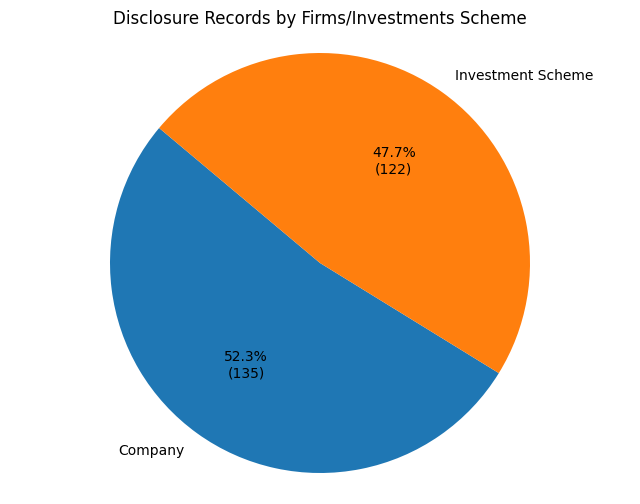

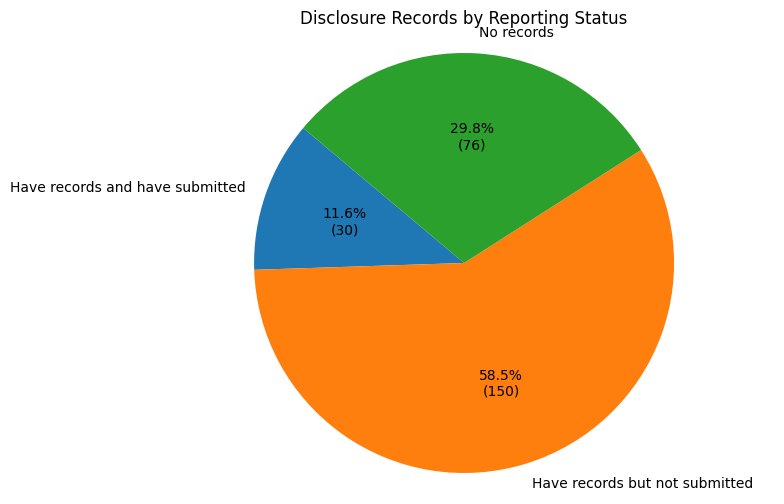

In [8]:
# Group by the 'Category' column and count the number of lines
grouped_data = master_disclosure.groupby('scheme').size()

# Function to format the labels with both count and percentage
def func(pct, allvals):
    absolute = int(pct/100.*sum(allvals))
    return f"{pct:.1f}%\n({absolute:d})"

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(grouped_data, labels=grouped_data.index, autopct=lambda pct: func(pct, grouped_data), startangle=140)
plt.title('Disclosure Records by Firms/Investments Scheme')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Group by the 'Category' column and count the number of lines
grouped_data = master_disclosure.groupby('status').size()

# Function to format the labels with both count and percentage
def func(pct, allvals):
    absolute = int(pct/100.*sum(allvals))
    return f"{pct:.1f}%\n({absolute:d})"

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(grouped_data, labels=grouped_data.index, autopct=lambda pct: func(pct, grouped_data), 
         startangle=140)
plt.title('Disclosure Records by Reporting Status')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


<Figure size 1400x800 with 0 Axes>

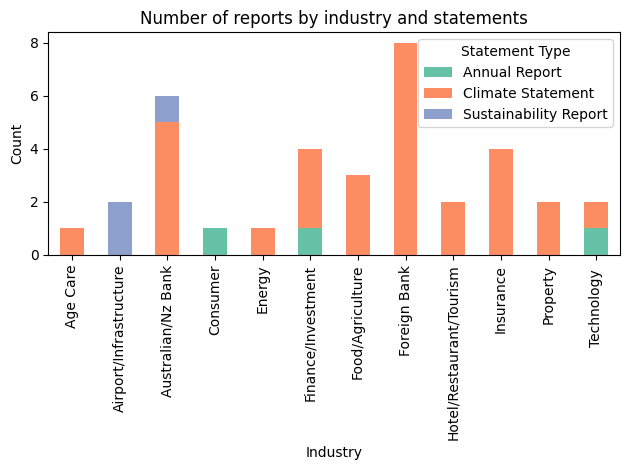

In [9]:
# Group by the 'Industry' column and count the number of lines
industry_counts = nlp_analysis.groupby(['industry','Category']).size().unstack(fill_value=0)

# Define a seaborn color palette
palette = sns.color_palette("Set2", n_colors=len(industry_counts.columns))

# Plotting the bar chart
plt.figure(figsize=(14, 8))
industry_counts.plot(kind='bar', stacked=True, color=palette)
plt.title('Number of reports by industry and statements')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.xticks(rotation=90, fontsize =10)
plt.legend(title='Statement Type')
plt.tight_layout()  # Adjusts plot to ensure everything fits without overlapping
plt.show()

<Figure size 600x600 with 0 Axes>

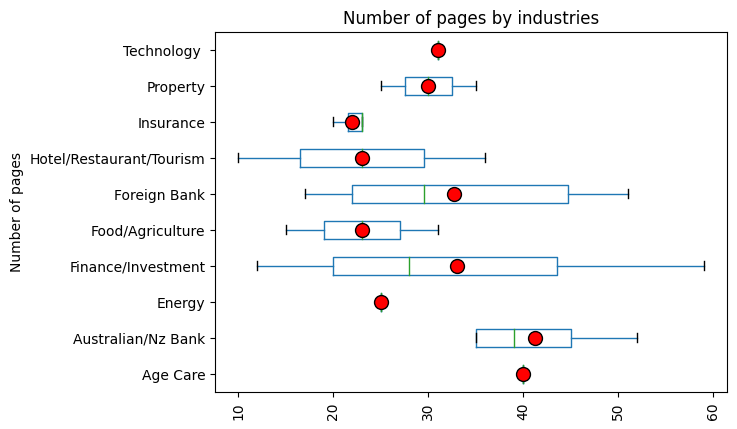

<Figure size 600x600 with 0 Axes>

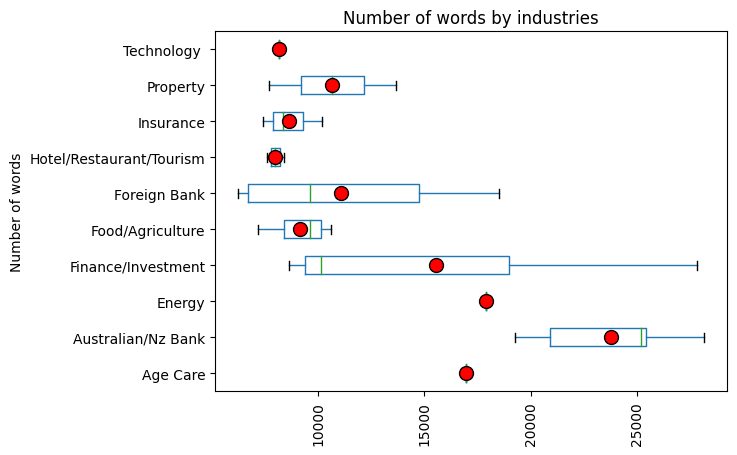

<Figure size 600x600 with 0 Axes>

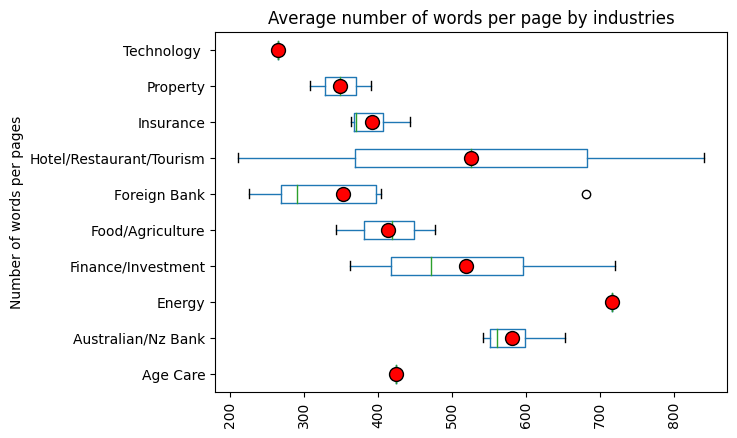

In [10]:
# Group by the 'Industry' column and count the number of lines
nlp_statement = nlp_analysis[nlp_analysis['Category'] =='Climate Statement']
nlp_statement = nlp_statement[nlp_statement['file_name'] !='SRLHA NZ CRD Statement_signed.pdf']

nlp_statement['words_per_page'] = nlp_statement['number_words']/ nlp_statement['pages_num']
group = nlp_statement['industry'].unique()
                       
# Define a seaborn color palette
palette = sns.color_palette("Set2", n_colors=len(group))

#PAGE 
# Create boxplot
plt.figure(figsize=(6, 6))
nlp_statement.boxplot(column='pages_num', by='industry',
                      showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black", "markersize": "10"},
                      grid=False, vert=False)

# Set plot title and labels
plt.title('Number of pages by industries')
plt.suptitle('')  # Suppress the default title to avoid redundancy
plt.xlabel('')
plt.ylabel('Number of pages')
plt.xticks(rotation=90, fontsize =10)

# Show plot
plt.show()

#WORD 
# Create boxplot
plt.figure(figsize=(6, 6))
nlp_statement.boxplot(column='number_words', by='industry',
                      showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black", "markersize": "10"},
                      grid=False, vert=False)
# Set plot title and labels
plt.title('Number of words by industries')
plt.suptitle('')  # Suppress the default title to avoid redundancy
plt.xlabel('')
plt.ylabel('Number of words')
plt.xticks(rotation=90, fontsize =10)

# Show plot
plt.show()

#PAGES 
# Create boxplot
plt.figure(figsize=(6, 6))
nlp_statement.boxplot(column='words_per_page', by='industry',
                      showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black", "markersize": "10"},
                      grid=False, vert=False)
# Set plot title and labels
plt.title('Average number of words per page by industries')
plt.suptitle('')  # Suppress the default title to avoid redundancy
plt.xlabel('')
plt.ylabel('Number of words per pages')
plt.xticks(rotation=90, fontsize =10)

# Show plot
plt.show()

In [11]:
nlp_statement[['pages_num','words_per_page','number_words',]].describe()

,pages_num,words_per_page,number_words
count,29.000000,29.000000,29.000000
mean,31.172414,442.742640,13381.827586
std,12.360851,165.525821,6925.219259
min,10.000000,210.861111,6245.000000
25%,23.000000,307.480000,7687.000000
50%,30.000000,404.136364,10179.000000
75%,39.000000,550.457143,17906.000000
max,59.000000,839.800000,28148.000000


<Figure size 600x600 with 0 Axes>

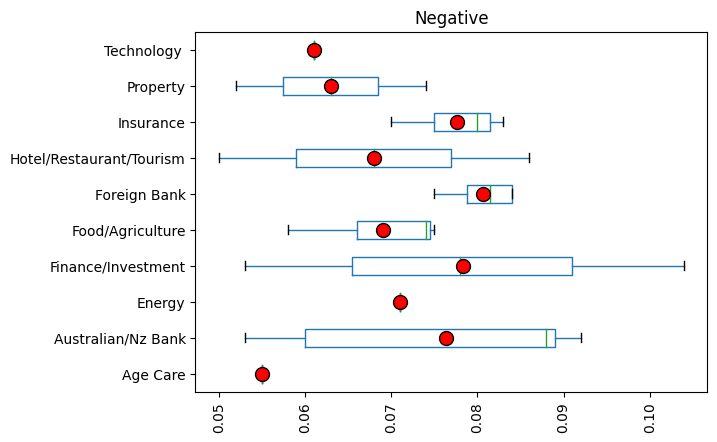

<Figure size 600x600 with 0 Axes>

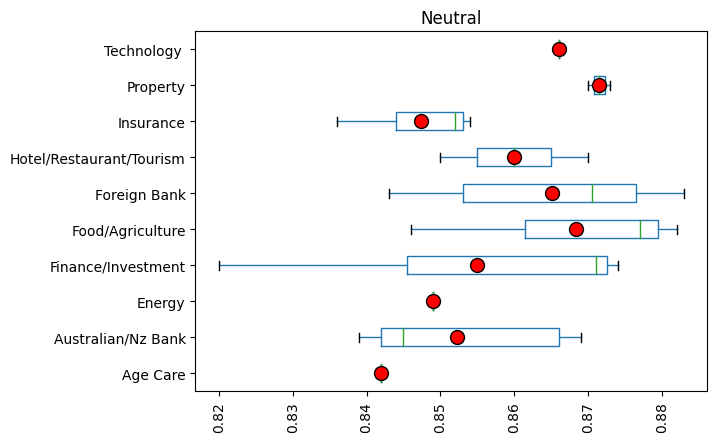

<Figure size 600x600 with 0 Axes>

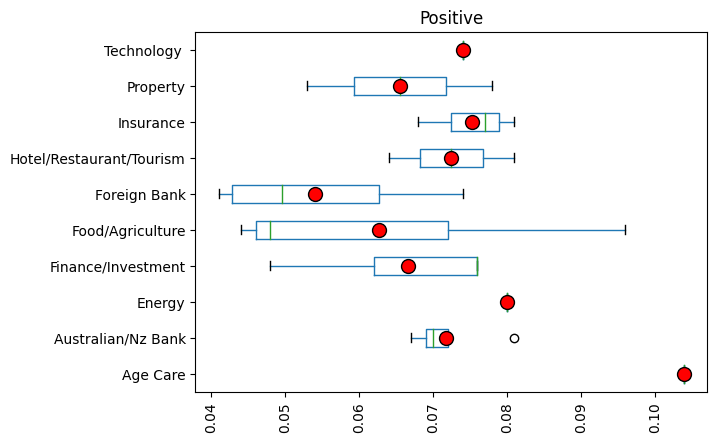

<Figure size 600x600 with 0 Axes>

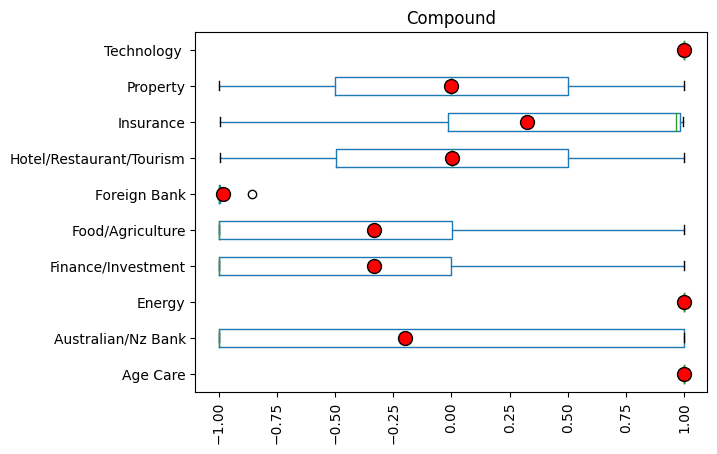

In [12]:
# DOCUMENT SENTIMENT 
# Group by the 'Industry' column and count the number of lines
nlp_statement = nlp_analysis[nlp_analysis['Category'] =='Climate Statement']
nlp_statement = nlp_statement[nlp_statement['file_name'] !='SRLHA NZ CRD Statement_signed.pdf']
group = nlp_statement['industry'].unique()

                       
# Define a seaborn color palette
palette = sns.color_palette("Set2", n_colors=len(group))

#PAGE 
# Create boxplot
plt.figure(figsize=(6, 6))
nlp_statement.boxplot(column='negative', by='industry',
                      showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black", "markersize": "10"},
                      grid=False, vert=False)

# Set plot title and labels
plt.title('Negative')
plt.suptitle('')  # Suppress the default title to avoid redundancy
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=90, fontsize =10)

# Show plot
plt.show()

#WORD 
# Create boxplot
plt.figure(figsize=(6, 6))
nlp_statement.boxplot(column='neutral', by='industry',
                      showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black", "markersize": "10"},
                      grid=False, vert=False)

# Set plot title and labels
plt.title('Neutral')
plt.suptitle('')  # Suppress the default title to avoid redundancy
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=90, fontsize =10)

# Show plot
plt.show()


#WORD 
# Create boxplot
plt.figure(figsize=(6, 6))
nlp_statement.boxplot(column='positive', by='industry',
                      showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black", "markersize": "10"},
                      grid=False, vert=False)
# Set plot title and labels
plt.title('Positive')
plt.suptitle('')  # Suppress the default title to avoid redundancy
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=90, fontsize =10)

# Show plot
plt.show()


#COUMPOUND 
# Create boxplot
plt.figure(figsize=(6, 6))
nlp_statement.boxplot(column='compound', by='industry',
                      showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black", "markersize": "10"},
                      grid=False, vert=False)

# Set plot title and labels
plt.title('Compound')
plt.suptitle('')  # Suppress the default title to avoid redundancy
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=90, fontsize =10)

# Show plot
plt.show()

In [13]:
nlp_statement[['negative','neutral','positive','compound']].describe()

,negative,neutral,positive,compound
count,29.000000,29.000000,29.000000,29.000000
mean,0.074172,0.859103,0.066862,-0.236752
std,0.013787,0.016365,0.016429,0.981004
min,0.050000,0.820000,0.041000,-0.999900
25%,0.061000,0.845000,0.052000,-0.999300
50%,0.075000,0.866000,0.070000,-0.996600
75%,0.084000,0.873000,0.077000,0.998700
max,0.104000,0.883000,0.104000,1.000000


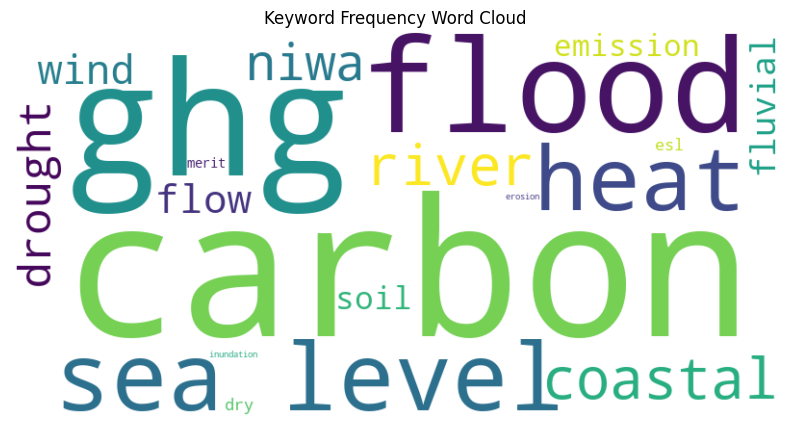

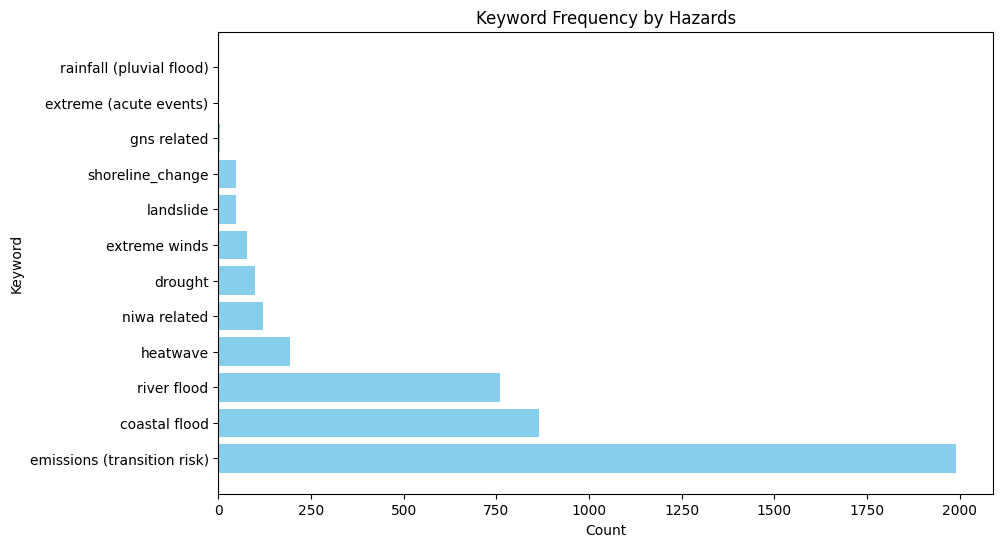

C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\3533984918.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  keyword_count_5.sort_values(by=['count'],inplace=True)


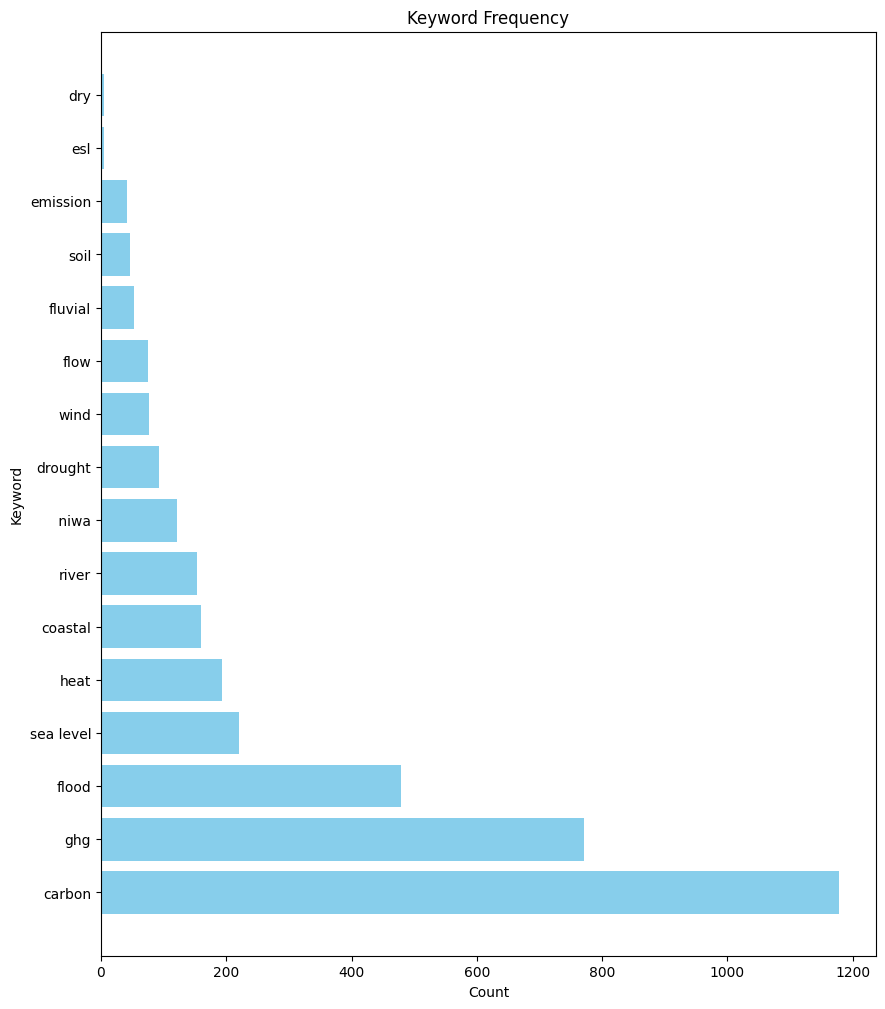

In [14]:
#sentiment
sent = SentimentIntensityAnalyzer()
st = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

## climate hazard datasets key words
drought = ['drought', 'severe drought', 'dry', 'SPI', 'standardised precipitation index', 'standardized precipitation index', 'rainfall', '10 minute average', 'topography']
winds= ['wind', 'extreme winds', 'cyclone','tsunami']
rainfall =['rain','pluvial','pluvial flooding','rainfall']
river = ['river','flood', 'river flooding', 'fluvial',
         'daily rainfall', 'river level', 'flow', 'soils', 'vegetation', 
        ]
coastal = ['coastal','flood','topography',  'sea-level', 'sea level', 'esl', 'extreme sea',
           'coastal flooding', 'inundation', 'groundwater','nearshore', 'bathymetry', 'bathymetric']
shoreline_change = ['shoreline change','aerial', 'aerial photography', 'historical aerial', 'topography', 'soils', 'soil', 'geology']
heatwave = ['heatwave', 'extreme temperature', 'humidity', 'rainfall', 'extreme heat', 'heat']
landslide =['landslide', 'soil', ' soil erosion', 'erosion', 'topography', 'geology', 'soils', 'vegetation', 'rainfall']
other = ['extreme event', 'extreme heat','extreme sea','extreme winds', 'disaster']
emissions = ['emission', 'carbon', 'ghg','greenhouse','methane',' ets ']
gns_related_words = [' gns', 'merit', 'riskscape','nigem','nz searise', 'groundwater', 'antarctica']
niwa_words = [' niwa']
## put climate hazards into a list to easily loop over
keywords= drought +  winds +  river +  coastal +  shoreline_change +  heatwave +  landslide + other + emissions + other +gns_related_words +niwa_words


#keyword count 
keyword_count = pd.DataFrame(nlp_statement[keywords].sum()).reset_index()
keyword_count.columns =['keyword','count']
keyword_count.drop_duplicates(subset=['keyword'],inplace=True)

# Create a dictionary from the DataFrame
word_freq = dict(zip(keyword_count['keyword'], keyword_count['count']))

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Keyword Frequency Word Cloud')
plt.show()

# Defining a function to count keywords based on given categories
def count_keywords_by_group(keyword_count, groups):
    group_counts = {}
    for group_name, keywords in groups.items():
        group_count = keyword_count[keyword_count['keyword'].isin(keywords)]['count'].sum()
        group_counts[group_name] = group_count
    return group_counts

# Defining the groups
groups = {
    'drought': drought,
    'extreme winds': winds,
    'rainfall (pluvial flood)': rainfall,
    'river flood': river,
    'coastal flood': coastal,
    'shoreline_change': shoreline_change,
    'heatwave': heatwave,
    'landslide': landslide,
    'extreme (acute events)': other,
    'emissions (transition risk)': emissions,
    'gns related':gns_related_words,
    'niwa related': niwa_words
}

# Calculating the counts for each group
group_counts = count_keywords_by_group(keyword_count, groups)

# Creating a DataFrame for the group counts
group_counts_df = pd.DataFrame(list(group_counts.items()), columns=['Group', 'Count'])
group_counts_df.sort_values(by=['Count'],inplace=True)

# Creating a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(group_counts_df['Group'], group_counts_df['Count'], color='skyblue')
plt.xlabel('Count')
plt.ylabel('Keyword')
plt.title('Keyword Frequency by Hazards')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest count on top
plt.show()


# Creating a horizontal bar chart
keyword_count_5 = keyword_count[keyword_count['count']>=5]
keyword_count_5.sort_values(by=['count'],inplace=True)
plt.figure(figsize=(10, 12))
plt.barh(keyword_count_5['keyword'], keyword_count_5['count'], color='skyblue')
plt.xlabel('Count')
plt.ylabel('Keyword')
plt.title('Keyword Frequency')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest count on top
plt.show()

In [15]:
keyword_count.to_csv(folder + 'keyword_count.csv')

In [16]:
#sentiment
sent = SentimentIntensityAnalyzer()
st = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

## climate hazard datasets key words
drought = ['drought', 'severe drought', 'dry', 'SPI', 'standardised precipitation index', 'standardized precipitation index', 'rainfall', '10 minute average', 'topography']
winds= ['wind', 'extreme winds', 'cyclone','tsunami']
rainfall =['rain','pluvial','pluvial flooding','rainfall']
river = ['river','flood', 'river flooding', 'fluvial',
         'daily rainfall', 'river level', 'flow', 'soils', 'vegetation', 
        ]
coastal = ['coastal','flood','topography',  'sea-level', 'sea level', 'esl', 'extreme sea',
           'coastal flooding', 'inundation', 'groundwater','nearshore', 'bathymetry', 'bathymetric']
shoreline_change = ['shoreline change','aerial', 'aerial photography', 'historical aerial', 'topography', 'soils', 'soil', 'geology']
heatwave = ['heatwave', 'extreme temperature', 'humidity', 'rainfall', 'extreme heat', 'heat']
landslide =['landslide', 'soil', ' soil erosion', 'erosion', 'topography', 'geology', 'soils', 'vegetation', 'rainfall']
other = ['extreme event', 'extreme heat','extreme sea','extreme winds', 'disaster']
emissions = ['emission', 'carbon', 'ghg','greenhouse','methane',' ets ']
gns_related_words = [' gns', 'merit', 'riskscape','nigem','nz searise', 'groundwater', 'antarctica']
niwa_words = [' niwa']
## put climate hazards into a list to easily loop over
keywords= drought +  winds +  river +  coastal +  shoreline_change +  heatwave +  landslide + other + emissions + other +gns_related_words +niwa_words


keyword_count = nlp_statement[['industry']+keywords].groupby('industry')[keywords].sum().reset_index()
keyword_count = keyword_count.loc[:,~keyword_count.columns.duplicated()].copy()

# Defining the keyword groups
groups = {
    'drought': drought,
    'extreme winds': winds,
    'rainfall (pluvial flood)': rainfall,
    'river flood': river,
    'coastal flood': coastal,
    'shoreline_change': shoreline_change,
    'heatwave': heatwave,
    'landslide': landslide,
    'extreme (acute events)': other,
    'emissions (transition risk)': emissions,
    'gns related':gns_related_words,
    'niwa related': niwa_words
}
# Filter the groups dictionary to only include keywords that are in the DataFrame columns
filtered_groups = {group: [keyword for keyword in keywords if keyword in keyword_count.columns] for group, keywords in groups.items()}

# Initialize the resulting DataFrame
result = pd.DataFrame(columns=filtered_groups.keys(), index=keyword_count['industry'])

# Calculate the sum for each group and industry
for industry in keyword_count['industry']:
    industry_data = keyword_count[keyword_count['industry'] == industry]
    for group, keywords in filtered_groups.items():
        result.loc[industry, group] = industry_data[keywords].sum(axis=1).values[0]

# Reset index to make 'industry' a column
result = result.reset_index()

result

,industry,drought,extreme winds,rainfall (pluvial flood),river flood,coastal flood,shoreline_change,heatwave,landslide,extreme (acute events),emissions (transition risk),gns related,niwa related
0,Age Care,0,4,0,10,11,0,8,0,0,104,1,4
1,Australian/Nz Bank,47,22,0,227,285,25,96,26,0,562,0,48
2,Energy,7,6,0,45,52,0,1,0,0,121,1,4
3,Finance/Investment,9,10,0,157,225,2,14,2,0,224,0,8
4,Food/Agriculture,9,8,0,32,25,18,13,18,0,166,0,13
5,Foreign Bank,23,20,0,189,145,0,46,0,0,437,0,19
6,Hotel/Restaurant/Tourism,0,1,0,25,30,0,4,0,0,95,0,4
7,Insurance,2,5,0,26,27,0,6,0,0,115,1,15
8,Property,1,1,0,46,63,2,4,2,0,115,0,6
9,Technology,0,0,0,3,2,0,2,0,0,52,0,0


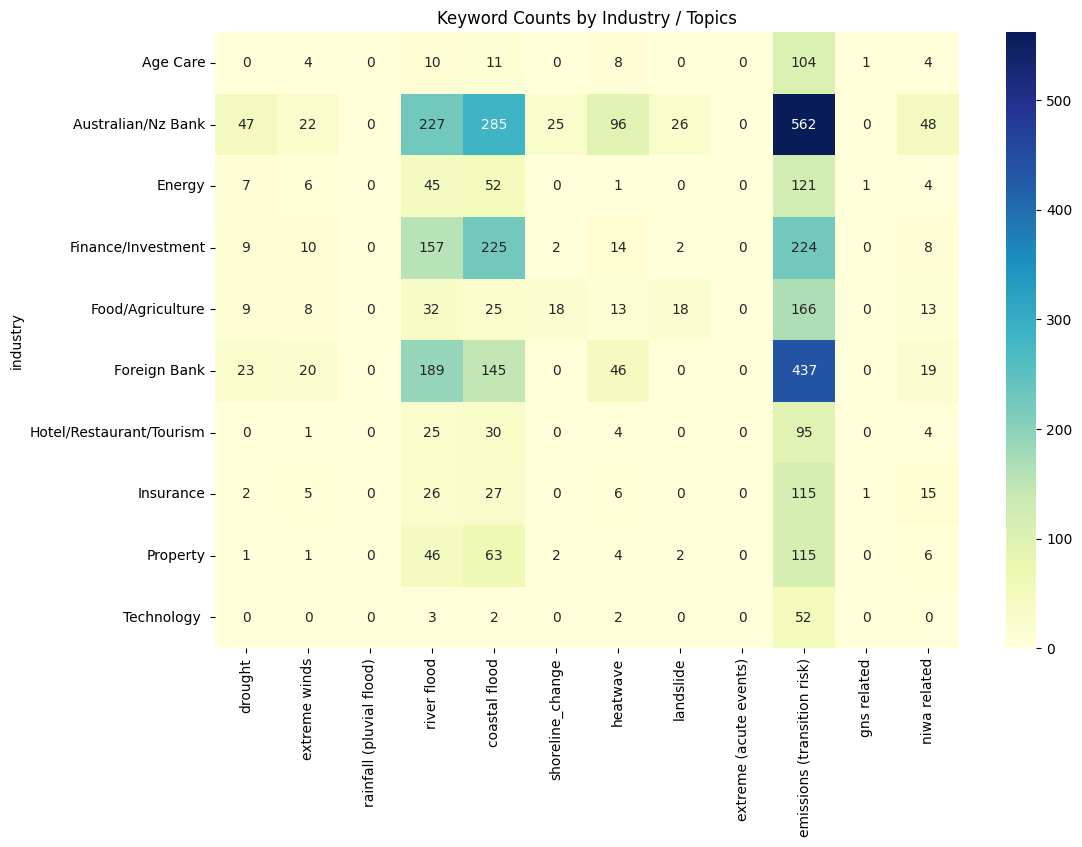

In [17]:
# Ensure all data in the result DataFrame is numeric
result.iloc[:, 1:] = result.iloc[:, 1:].apply(pd.to_numeric)

result[['drought', 'extreme winds', 'rainfall (pluvial flood)',
       'river flood', 'coastal flood', 'shoreline_change', 'heatwave',
       'landslide', 'extreme (acute events)', 'emissions (transition risk)', 'gns related',
    'niwa related']]= \
result[['drought', 'extreme winds', 'rainfall (pluvial flood)',
       'river flood', 'coastal flood', 'shoreline_change', 'heatwave',
       'landslide', 'extreme (acute events)', 'emissions (transition risk)', 'gns related',
    'niwa related']].astype(int)

# Draw the heatmap by keywords 
plt.figure(figsize=(12, 8))
sns.heatmap(result.set_index('industry'), annot=True, cmap='YlGnBu', fmt='g')
plt.title('Keyword Counts by Industry / Topics')
plt.show()



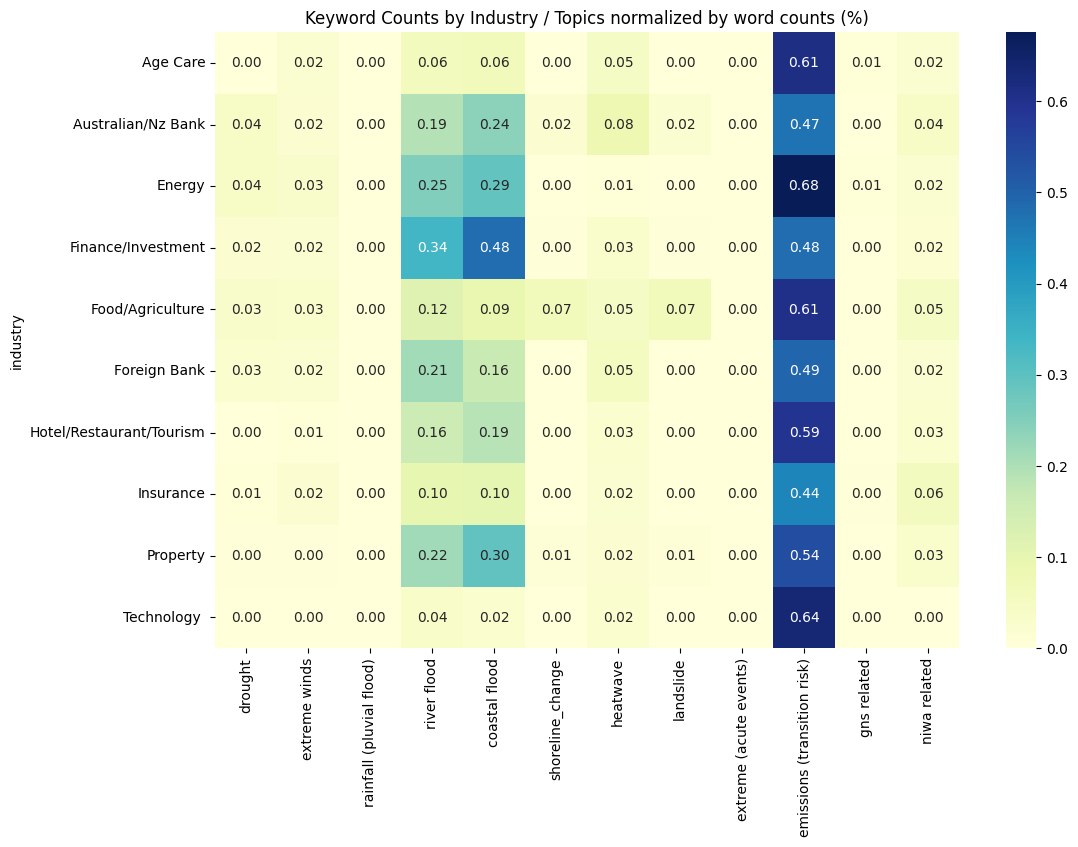

In [18]:
word_counts_industry  = nlp_statement[['number_words','industry']].groupby('industry').sum().reset_index()
result_normalized = pd.merge(result, word_counts_industry,
                            how = 'left',
                            left_on = ['industry'],
                            right_on = ['industry'])
columns_to_normalize = ['drought', 'extreme winds', 'rainfall (pluvial flood)',
                        'river flood', 'coastal flood', 'shoreline_change', 'heatwave',
                        'landslide', 'extreme (acute events)', 'emissions (transition risk)',
                        'gns related', 'niwa related']

result_normalized[columns_to_normalize] = result_normalized[columns_to_normalize].div(result_normalized['number_words'], axis=0)
# Convert the normalized values to percentages
result_normalized[columns_to_normalize] = result_normalized[columns_to_normalize] * 100

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(result_normalized.set_index('industry')[columns_to_normalize], annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Keyword Counts by Industry / Topics normalized by word counts (%)')
plt.show()


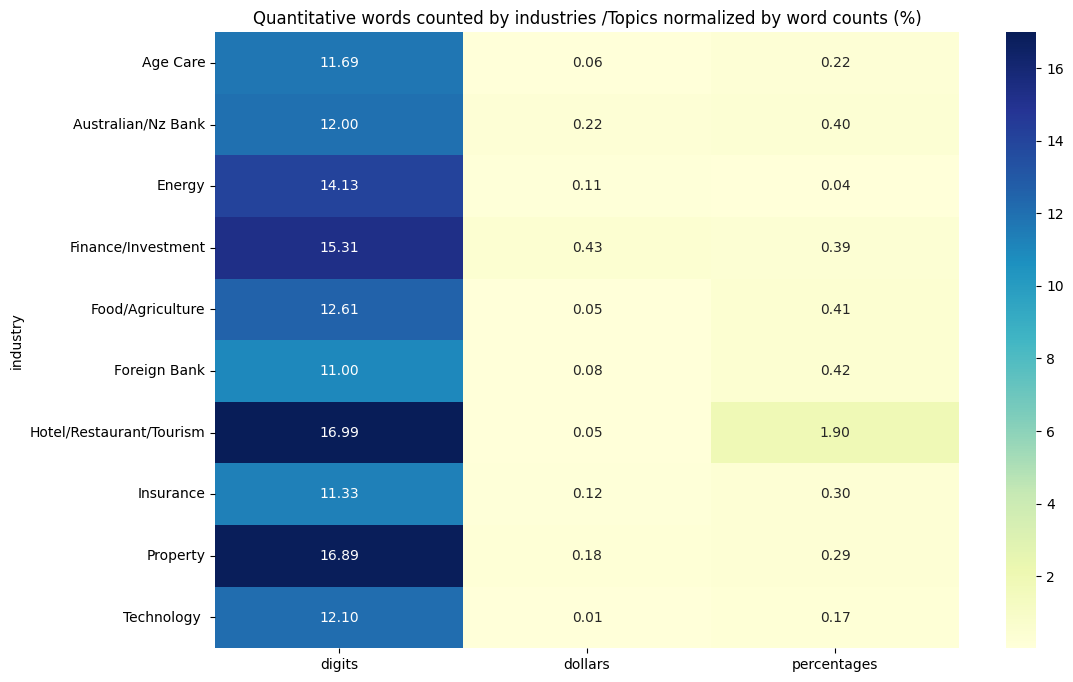

In [19]:
quantitative  = nlp_statement[['industry', 'digits','dollars','percentages']].groupby('industry').sum().reset_index()
word_counts_industry  = nlp_statement[['number_words','industry']].groupby('industry').sum().reset_index()

quantitative_normalized = pd.merge(quantitative, word_counts_industry,
                            how = 'left',
                            left_on = ['industry'],
                            right_on = ['industry'])
columns_to_normalize = ['digits','dollars','percentages']

quantitative_normalized[columns_to_normalize] = quantitative_normalized[columns_to_normalize].div(quantitative_normalized['number_words'], axis=0)
# Convert the normalized values to percentages
quantitative_normalized[columns_to_normalize] = quantitative_normalized[columns_to_normalize] * 100

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(quantitative_normalized.set_index('industry')[columns_to_normalize], annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Quantitative words counted by industries /Topics normalized by word counts (%)')
plt.show()


In [20]:
import spacy
from spacy import displacy
from collections import Counter
import en_core_web_sm
nlp = en_core_web_sm.load()

#Simple analysis 
text_directory  = 'C:/Users/QuyenN/Offline work/2. GNS/5-Climate risk disclosure/text/'   
text_directory_list =  os.listdir(text_directory)

organization_list_final = pd.DataFrame()
for file_name in text_directory_list:
    print(file_name)
    try:
        
        with open(f"{text_directory}/{file_name}", encoding="latin-1") as file:
            #clean data 
            page_text_clean = file.read() 
            #sentiment analysis 
            doc = nlp(page_text_clean)
            classification = [(X.text, X.label_) for X in doc.ents]
            organization_list = pd.DataFrame(classification, columns=['Value', 'Type'])
            organization_list = organization_list [organization_list ['Type']== 'ORG']
            organization_list['file_name'] = file_name
            organization_list_final  = pd.concat([organization_list_final, organization_list], ignore_index=True)
    except: 
        print('Error')
        
organization_list_final.to_csv(f'{folder}/result/organization_list_final.csv', encoding='latin-1', index=False)


2023 12 31 - PFI - Climate-related Disclosures - Signed.txt
2023 Climate Statements for Citibank N.A. (New Zealand Branch).txt
AIA NZ Climate Related Disclosers Report FINAL_signed.txt
ANZ_climate-report-2023.txt
asb-climate-report-2022.txt
Bank of China (New Zealand) Limited Climate Related Disclosure for the year ended 31 December 2023.txt
Bank of China New Zealand Banking Group Climate Related Disclosure for the year ended 31 December 2023.txt
BNZ_2023-Climate-Report.txt
Briscoe Group 2024 Annual Report.txt
CCBNZBG Climate Report for the year ended 31 December 2023.txt
CCBNZL Climate Report for the year ended 31 December 2023.txt
CDL0017_Climate_Related_Disclosures_2023.txt
Chubb Life Insurance New Zealand Limited Climate Disclosure 2023.txt
Citibank N.A. (New Zealand Branch) - Statement - 29 APRIL 2024 .txt
Climate-Report-2023-Westpac-NZ.txt
CRD 2023 CEO Declaration.txt
HSBC NZ 2023 Climate Statement lodgement letter - signed.txt
ICBC Ltd CRD 31 Dec 23  Final - For submission.txt
I

In [21]:
organization_list_final['clean_value'] = organization_list_final['Value'].apply(lambda text: clean_data(text))
organization_list_final_summary = organization_list_final.groupby(['clean_value']).count().reset_index()
organization_list_final_summary.head(5)
organization_list_final =pd.merge(organization_list_final, organization_list_final_summary[['clean_value','Value']],
                                 how = 'left',
                                 left_on = 'clean_value',
                                 right_on = 'clean_value')
organization_list_final.head(5)

,Value_x,Type,file_name,clean_value,Value_y
0,DocuSign Envelope,ORG,2023 12 31 - PFI - Climate-related Disclosures...,docusign envelop,56
1,PFI,ORG,2023 12 31 - PFI - Climate-related Disclosures...,pfi,197
2,DocuSign Envelope,ORG,2023 12 31 - PFI - Climate-related Disclosures...,docusign envelop,56
3,Industry Limited,ORG,2023 12 31 - PFI - Climate-related Disclosures...,industri limit,1
4,NZX,ORG,2023 12 31 - PFI - Climate-related Disclosures...,nzx,547


In [22]:
organization_list_final.rename(columns ={'Value_x':'Value',
                                        'Value_y':'count'},
                              inplace=True)
organization_list_final.to_csv(f'{folder}/result/organization_list_final_summary.csv', encoding='latin-1', index=False)

## CODING ANALYSIS BASED ON CHAT GPT 

- [q1 What is the Word counts/ Page counts/ Length of document?](#section-1)
- [q2 Is the disclosure issued as a separate climate statement, sustainability report, or annual report?](#section-2)
- [q3 List the adoption provisions that this statement applies. If no, please answer NA](#section-3)
- [q4 Provide the list of all climate scenarios or pathways that have been used in this statement](#section-4)
- [q5 Provide the global temperature outcomes associated with the climate scenarios by 2100](#section-5)
- [q6 Provide the list of scenario providers used in this statement](#section-6)
- [q7 Are the scenarios included a pick and mix of different scenario providers, such as SSPs or RCPs?](#section-7)
- [q8 Are the scenarios off-the-shelf or are they further customized to meet with company business models?](#section-8)
- [q9 What are the main variables that are covered and drive the scenarios?](#section-9)
- [q10 Are the scenarios/assessments being co-produced?](#section-10)
- [q11 Is there disclosure of the baseline or reference scenarios?](#section-11)
- [q12 What climate models/integrated assessment models/macro-economic models are used?](#section-12)
- [q13 Is damage from extreme or acute climate events considered?](#section-13)
- [q14 Are the scenarios based on global or local, New Zealand based models or regional models?](#section-14)
- [q15 What are the short, medium, and long term timeframes and their associated rationale?](#section-15)
- [q16 Does the statement provide justification for their choice of climate scenarios/models?](#section-16)
- [q17 What are the physical hazards listed in the climate statement that have an impact on firms?](#section-17)
- [q18 Is the discussion of physical risk generic or based on the geo-locations of its assets?](#section-18)
- [q19 What are the business risks specific to the firm due to physical hazards?](#section-19)
- [q20 What are the opportunities specific to the business due to physical hazards?](#section-20)
- [q21 Is there any quantification of the business exposure to physical hazards across climate scenarios?](#section-21)
- [q22 Are the current financial impacts of climate change discussed in the disclosure? What are they?](#section-22)
- [q23 Are the future financial impacts of climate change discussed in the disclosure? What are they?](#section-23)
- [q24 Is there disclosure of the range of uncertainty?](#section-24)
- [q25 Are the financial impacts detailed quantitatively or qualitatively?](#section-25)
- [q26 Are the disclosure of financial impact focus on direct or indirect loss?](#section-26)
- [q27 Did science agencies involve in the creation of this disclosure?](#section-27)
- [q28 Did science agencies involve in terms of providing the climate scenarios?](#section-28)
- [q29 Was a consultancy employed to conduct part, or all, of the disclosure?](#section-29)
- [q30 What parts of the disclosures are consultants commonly contracted?](#section-30)
- [q31 Is the overall discussion about climate risk neutral/negative/positive?](#section-31)
- [q32 Is climate risk expected to have a significant impact on the company's financial performance?](#section-32)
- [q33 Is the overall discussion in the document qualitative/quantitative (%)/financially quantitative?](#section-33)

In [59]:
#generate a dictionary of question 
query_dict = {
'q1': 'What is the Word counts/ Page counts/ Length of document?',
'q2': 'Is the climate risk disclosure issued as a separate climate statement, sustainablity report, or annual report?',
'q3': 'List the adoption provisions that this statement applies. If no, plaese answer NA',
'q4': 'Provide the list of all climate scenarios or pathways that have been used in this statement', 
'q5': 'Provide the global temperature outcomes associated with the climate scenarios by 2100',
'q6': 'Provide the list of scenario providers used in this statement',
'q7': 'Are the scenarios included a pick and mix of different scenario providers, such as SSPs or RCPs?', 
'q8': 'Are the scenarios off-the-shelf or are they further customized to meet with company business models?',
'q9': 'What are the main variables that are covered and drive the scenarios? (apart from global temperature outcomes)?',
'q10': 'Are the scenarios/assessments being co-produced ?  For instance, are there keywords like ‘participatory’, ‘co-creat$’, ‘deliber$’, ‘co-design$’ which might be indicative of the legitimacy of the scenarios?',
'q11': 'Is there disclosure of the  baseline or reference scenarios or assumptions that is used to measure the impact of climate change scenarios against?',
'q12': 'What climate models/ integrated assessment models / macro-economic models used in the creation of scenarios?',
'q13': 'Is damage from extreme or acute climate events considered in the set of climate scenarios/ pathways?',
'q14': 'Are the scenarios based on global climate models or local, New Zealand based models or regional models?',
'q15': 'What are the short, medium and long term timeframes and their associated rationale?',
'q16': 'Does the statement provide justification for their choice of climate scenarios/ models?',
'q17': 'What are the physical hazards listed in the climate statement that have an impact on firms?',
'q18': 'Is the discussion of physical risk generic or based on the geo-locations of its assets?',
'q19': 'What are the business risks specific to the firm due to physical hazards?',
'q20': 'What are the opportunities specific to the business due to physical hazards?',
'q21': 'Is there any quantification of the business exposure to physical hazards across climate scenarios ? What are they?', 
'q22': 'Are the current financial impacts of climate change discussed in the disclosure? What are they?',
'q23': 'Are the future financial impacts of climate change discussed in the disclosure? What are they?', 
'q24': 'Is there disclosure of the range of uncertainty surrounding the expected (average - mean) exposure and financial impacts due to climate physical hazards?',
'q25': 'Are the financial impacts detailed  quantatively or qualitatively?',
'q26': 'Are the disclosure of financial impact focus on direct or indirect loss?',
'q27': 'Did science agencies  involve in the creation of this disclosure? What are they? (for instance, NIWA)?',
'q28': 'Did science agencies involve in terms of providing the climate scenarios/consulting on the identification of climate risk and opportunities/ analysis of climate physical risk, hazard, exposure/ providing datasets or analysis of current/ anticipated impacts?',
'q29': 'Was a consultancy employed to conduct part, or all, of the disclosure?',
'q30': 'What parts of the disclosures (climate risk/ scenario creation/ data provision / transition risk) are consultants commonly contracted',
'q31': 'Is the overall discussion about climate risk neutral/ negative / positve ?',
'q32': "Is climate risk expected to have a significant impact on the company's financial performance?",
'q33': 'Is the overall discussion in the document qualitative / quantitative (%) / financially quantitative ($)?'
}


query_short_dict = {
    'q1': 'Word/Page counts',
    'q2': 'Disclosure type',
    'q3': 'Adoption provisions',
    'q4': 'Climate scenarios',
    'q5': 'Temperature outcomes',
    'q6': 'Scenario providers',
    'q7': 'Mix of scenarios',
    'q8': 'Custom scenarios',
    'q9': 'Main variables',
    'q10': 'Co-produced scenarios',
    'q11': 'Baseline scenarios',
    'q12': 'Models used',
    'q13': 'Extreme events',
    'q14': 'Model type',
    'q15': 'Timeframes',
    'q16': 'Scenario justification',
    'q17': 'Physical hazards',
    'q18': 'Physical risk detail',
    'q19': 'Business risks',
    'q20': 'Business opportunities',
    'q21': 'Exposure quantification',
    'q22': 'Current impacts',
    'q23': 'Future impacts',
    'q24': 'Uncertainty range',
    'q25': 'Impact detail',
    'q26': 'Impact focus',
    'q27': 'Science agencies',
    'q28': 'Agency involvement',
    'q29': 'Consultancy',
    'q30': 'Consulted parts',
    'q31': 'Risk discussion',
    'q32': 'Risk impact',
    'q33': 'Discussion type'
}

template_dict = {
    
'q4': 
"""
You're given answer for question below. 
-----------------------------------
Provide the list of all climate scenarios or pathways that have been used in this statement
-----------------------------------
You need to code those answers into a list of scenarios following the exact format provided below. 
For instance, original answer is :
-----------------------------------
"The statement mentions three climate scenarios: an 'orderly' 1.5Â°C scenario, a 'hot house world' > 3Â°C scenario, and an in-between 'disorderly' scenario where global warming is limited to less than 2Â°C."
-----------------------------------
It should be transformed to Python list , no quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
[orderly 1.5C scenario;  hot house world > 3°C scenario;  disorderly scenario less than 2C]
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",
    
    
'q5':
"""
You're given answer for question below. 
-----------------------------------
Provide the global temperature outcomes associated with the climate scenarios by 2100
-----------------------------------
You need to code those answers into a list of temperature outcome following the exact format provided below.
For instance, original answer is :
-----------------------------------
"The global temperature outcomes associated with the climate scenarios by 2100 are as follows:
- 'Orderly' scenario: 1.5Â°C
- 'Too Little Too Late' scenario: >2Â°C
- 'Hothouse' scenario: >3Â°C."
-----------------------------------
It should be transformed to Python list , no quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
[1.5oC; >2oC;  >3oC]
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",
    
    'q6': 
"""
You're given answer for question below. 
-----------------------------------
Provide the global temperature outcomes associated with the climate scenarios by 2100
-----------------------------------
You need to code those answers into a list of temperature outcome following the exact format provided below.
For instance, original answer is :
-----------------------------------
"The global temperature outcomes associated with the climate scenarios by 2100 are as follows:
- 'Orderly' scenario: 1.5Â°C
- 'Too Little Too Late' scenario: >2Â°C
- 'Hothouse' scenario: >3Â°C."
-----------------------------------
It should be transformed to Python list , no quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
[1.5oC; >2oC;  >3oC]
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",
    'q7':
"""
You're given answer for question below. 
-----------------------------------
Are the scenarios included a pick and mix of different scenario providers, such as SSPs or RCPs?
-----------------------------------
You need to code those answers into a Yes/No/Undefined answer following the exact format provided below.
For instance, original answer is :
-----------------------------------
" Yes, the scenarios included a pick and mix of different scenario providers, such as SSPs or RCPs."
-----------------------------------
It should be transformed to  Yes/No/Undefined answer, no quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
Yes
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",
    'q8':
"""
You're given answer for question below. 
-----------------------------------
Are the scenarios off-the-shelf or are they further customized to meet with company business models?
-----------------------------------
You need to code those answers into a Off the shelf/Industry-specific scenarios/Company-specific scenarios answer following the exact format provided below.
For instance, original answer is :
-----------------------------------
" The scenarios used by ANZ are a combination of off-the-shelf scenarios from sources such as the Intergovernmental Panel on Climate Change (IPCC) and the Network for Greening the Financial System (NGFS), as well as ANZ-specific climate scenario narratives developed by the bank. These scenarios are further customized to meet the specific needs and business models of ANZ and are used to assess climate-related risks and opportunities for customers in the sectors they lend to.
"
-----------------------------------
It should be transformed to Off the shelf/Industry-specific scenarios/Company-specific scenarios , no quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
Company-specific scenarios
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",
    'q9':
"""
You're given answer for question below. 
-----------------------------------
What are the main variables that are covered and drive the scenarios? (apart from global temperature outcomes)?
-----------------------------------
You need to code those answers into a list of variables  following the exact format provided below.
For instance, original answer is :
-----------------------------------
" The main variables that are covered and drive the scenarios are access to water, changes in biodiversity and ecosystems, new technology advances and sustainable farming practices, changing global demand and consumer behavior, and severe acute and chronic weather events.
"
-----------------------------------
It should be transformed to Python list , no quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
[access to water; changes in biodiversity and ecosystems;  new technology advances and sustainable farming practices;changing global demand and consumer behavior;severe acute and chronic weather events;]
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",
    'q10':
"""
You're given answer for question below. 
-----------------------------------
Are the scenarios/assessments being co-produced ?  For instance, are there keywords like 'participatory', 'co-creat', 'deliber','co-design' which might be indicative of the legitimacy of the scenarios?
-----------------------------------
You need to code those answers into a categorical answer following the exact format provided below.
For instance, original answer is :
-----------------------------------
" Based on the given context, it does not appear that the scenarios/assessments are being co-produced. There are no keywords mentioned that suggest a participatory or collaborative approach to developing the scenarios. The process seems to be primarily driven by the Bank and its own internal analysis and engagement.
"
-----------------------------------
It should be transformed to Yes-co-produced/No/Maybe/Not sure , no quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
No
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",
    
    'q11':
"""
You're given answer for question below. 
-----------------------------------
Is there disclosure of the  baseline or reference scenarios or assumptions that is used to measure the impact of climate change scenarios against?
-----------------------------------
You need to code those answers into a categorical answer following the exact format provided below.
For instance, original answer is :
-----------------------------------
"  Yes, there is disclosure of uncertainties and limitations in the report, including the use of assumptions and estimates in data and modelling. However, there is no specific mention of a baseline or reference scenario used to measure the impact of climate change scenarios against."

-----------------------------------
It should be transformed to Yes -baseline scenarios mentioned/Yes -baseline variables mentioned/Maybe/No-no baseline metioned/Not sure quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
No-no baseline metioned
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",
    
    'q12':
"""
You're given answer for question below. 
-----------------------------------
What climate models/ integrated assessment models / macro-economic models used in the creation of scenarios?
-----------------------------------
You need to code those answers into a list of variables  following the exact format provided below.
For instance, original answer is :
-----------------------------------
"  The climate models/integrated assessment models/macro-economic models used in the creation of scenarios include the S&P Global Climanomics platform and NIWA's extreme sea level flood maps.
-----------------------------------
It should be transformed to Python list , no quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
[S&P Global Climanomics platform, NIWA's extreme sea level flood maps]
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",
    
    'q13':
"""
You're given answer for question below. 
-----------------------------------
Is damage from extreme or acute climate events considered in the set of climate scenarios/ pathways?
-----------------------------------
You need to code those answers into a categorical answer following the exact format provided below.
For instance, original answer is :
-----------------------------------
"   Yes, damage from extreme or acute climate events is considered in the set of climate scenarios/pathways. The report evaluates how climate may impact banks' credit risk for seven sectors, including agriculture, transport, energy, manufacturing, construction, and commercial and residential property. These scenarios also take into account potential risks and opportunities for these sectors in the face of extreme or acute climate events"
-----------------------------------
It should be transformed to Yes/No/Maybe/Not sure , no quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
Yes
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",
    
    
    'q14':
"""
You're given answer for question below. 
-----------------------------------
Are the scenarios based on global climate models or local, New Zealand based models or regional models?
-----------------------------------
You need to code those answers into a categorical answer following the exact format provided below.
For instance, original answer is :
-----------------------------------
"  The scenarios are based on global climate models."
-----------------------------------
It should be transformed to Global model/Regional model/New Zealand model/Not sure/Combined model, no quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
Global model
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",        
    
    
    'q15':
"""
You're given answer for question below. 
-----------------------------------
What are the short, medium and long term timeframes and their associated rationale?
-----------------------------------
You need to code those answers into a Python dictionary  following the exact format provided below.
For instance, original answer is :
-----------------------------------
"  The short, medium, and long term timeframes are 2030, 2050, and 2100, respectively. These timeframes align with different strategic planning horizons and global emissions reduction targets, and help ANZ understand how physical risks may change for future generations.
"
-----------------------------------
It should be transformed to a Python dictionary , no quote, no special characters, no \n. with ";" as delimiter.
-----------------------------------
['short term': 2030, 'medium term': 2050, 'long term': 2100]
-----------------------------------
Now do this for the below answer.
{answer}
-----------------------------------
""",        
    
}


In [54]:
query_df = pd.DataFrame([query_dict]).T.reset_index()
query_short_df = pd.DataFrame([query_short_dict]).T.reset_index()
query_df_final = pd.merge(query_df,query_short_df, how = 'left', left_on = 'index', right_on ='index')
query_df_final.rename(columns={'0_x':'Question','0_y':'Topic'}, inplace=True)
query_df_final.to_csv(folder + 'result/query_df_final.csv')

In [55]:
def run_langchain(text, max_tokens, expected_response_tokens ):
    token_count = get_token_count(text)
    template_count = get_token_count(template)
    if (token_count + template_count) <= (max_tokens - expected_response_tokens):
        return OpenAI_chain.run({"answer": text})
    else:
        return "Text exceeds the token limit ({} tokens, {} is maximum)".format((token_count + template_count + expected_response_tokens), max_tokens)

## SCENARIO ANALYSIS 

In [62]:
#DO NOT RUN THIS IF YOU ARE NOT SURE 
#Testing 
results_final  = pd.DataFrame()
for question in ['q4','q5','q6','q7','q8']:
    print(question)
    question_longname = query_dict[question] 
    question_shortname = query_short_dict[question]
    template = template_dict[question]
    answers =  dict(zip(full_answers['filename'], full_answers[question_longname]))
    ##
    prompt = PromptTemplate.from_template(template)
    OpenAI_chain = LLMChain(llm=llm, prompt=prompt)
    results = dict()
    for file_name, answer  in answers.items():
        result = run_langchain(answer, real_max_tokens, expected_response_tokens)
        results[file_name] = result
    results_df = pd.DataFrame([results]).T.reset_index()
    results_df.columns = ['filename','answer']
    results_df['question'] = question 
    results_final  =  pd.concat([results_final, results_df], ignore_index =True) 
results_final.to_csv(folder + 'result/question_coded_chatgpt.csv')

q4
q5
q6
q7
q8


In [60]:
#DO NOT RUN THIS IF YOU ARE NOT SURE 
#Testing 
results_final  = pd.DataFrame()
for question in ['q9','q10','q11','q12','q13','q14','q15']:
    print(question)
    question_longname = query_dict[question] 
    question_shortname = query_short_dict[question]
    template = template_dict[question]
    answers =  dict(zip(full_answers['filename'], full_answers[question_longname]))
    ##
    prompt = PromptTemplate.from_template(template)
    OpenAI_chain = LLMChain(llm=llm, prompt=prompt)
    results = dict()
    for file_name, answer  in answers.items():
        result = run_langchain(answer, real_max_tokens, expected_response_tokens)
        results[file_name] = result
    results_df = pd.DataFrame([results]).T.reset_index()
    results_df.columns = ['filename','answer']
    results_df['question'] = question 
    results_final  =  pd.concat([results_final, results_df], ignore_index =True) 
results_final.to_csv(folder + 'result/question_coded_chatgpt_q9_q15.csv')

q9
q10
q11
q12
q13
q14
q15


C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\1823683883.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q4['answer'] = q4['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


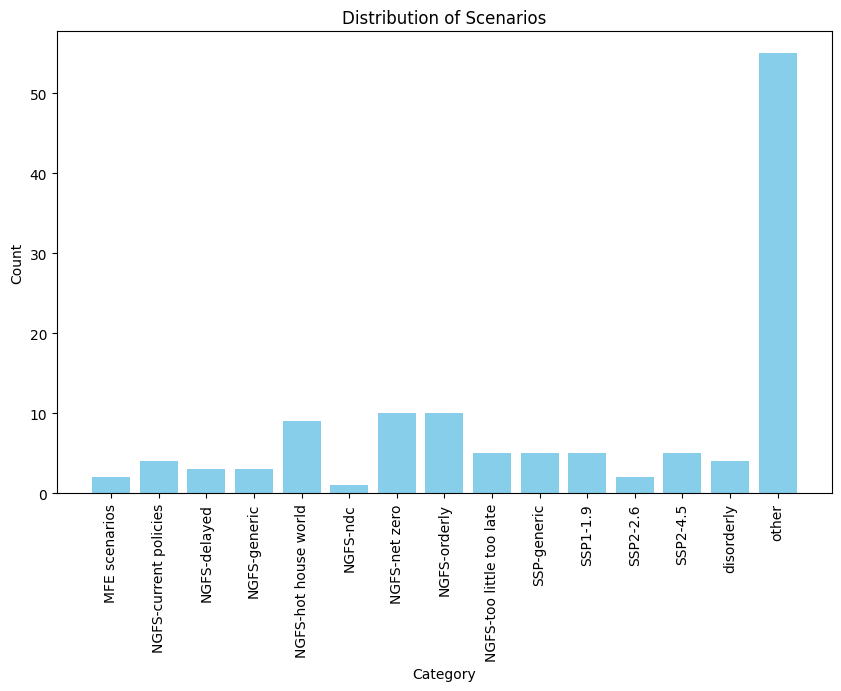

In [63]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt.csv')
#Question 4 - Scenario list 
q4 = results_final[results_final['question']=='q4']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list

# Function to manually standardize items
def standardize_item(item):
    item = item.lower()
    if 'fragmen' in item:
        return 'NGFS-fragment'
    elif 'ndc' in item:
        return 'NGFS-ndc'
    elif 'disorderly' in item:
        return 'disorderly'
    elif 'net z' in item:
        return 'NGFS-net zero'
    elif 'orderly' in item:
        return 'NGFS-orderly'
    elif 'too little too late' in item or 'too little, too late' in item:
        return 'NGFS-too little too late'
    elif 'hot house' in item or 'hothouse' in item:
        return 'NGFS-hot house world'
    elif 'delayed' in item :
        return 'NGFS-delayed'
    elif 'current policies' in item:
        return 'NGFS-current policies'
    elif ( 'shared ' or 'ssp' ) and ('1.9') in item:
        return 'SSP1-1.9'
    elif ( 'shared ' or 'ssp' ) and ('2.6') in item:
        return 'SSP2-2.6'
    elif ( 'shared ' or 'ssp' ) and ('4.5') in item:
        return 'SSP2-4.5'
    elif ( 'shared ' or 'ssp' )in item:
        return 'SSP-generic'
    elif ( 'network ' )in item:
        return 'NGFS-generic'
    elif ('ministry') in item:
        return 'MFE scenarios'
    else:
        return 'other'

# Applying the function to the DataFrame column
q4['answer'] = q4['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(q4['answer'] ) for item in sublist]
flattened_list

# Standardizing the list
standardized_list = dict()
for item in flattened_list:
    if isinstance(item, list):
        for sub_item in item:
            standardized_list[sub_item] = standardize_item(sub_item)
    else:
        standardized_list[item] = standardize_item(item)


# Counting occurrences of each category
standardized_df = pd.DataFrame([standardized_list]).T.reset_index()
standardized_df.columns =  columns=['original', 'code']
category_counts = standardized_df.groupby(['code']).count().reset_index()
category_counts.columns = ['Category','Count']

# Sorting the categories alphabetically
sorted_df = category_counts.sort_values(by='Category').reset_index(drop=True)

# Drawing the bar chart
plt.figure(figsize=(10, 6))
plt.bar(sorted_df['Category'], sorted_df['Count'], color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Distribution of Scenarios')
plt.xticks(rotation=90)

pd.DataFrame([standardized_list]).T.to_csv(folder + 'result/standardized_list.csv')

C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\2986874864.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


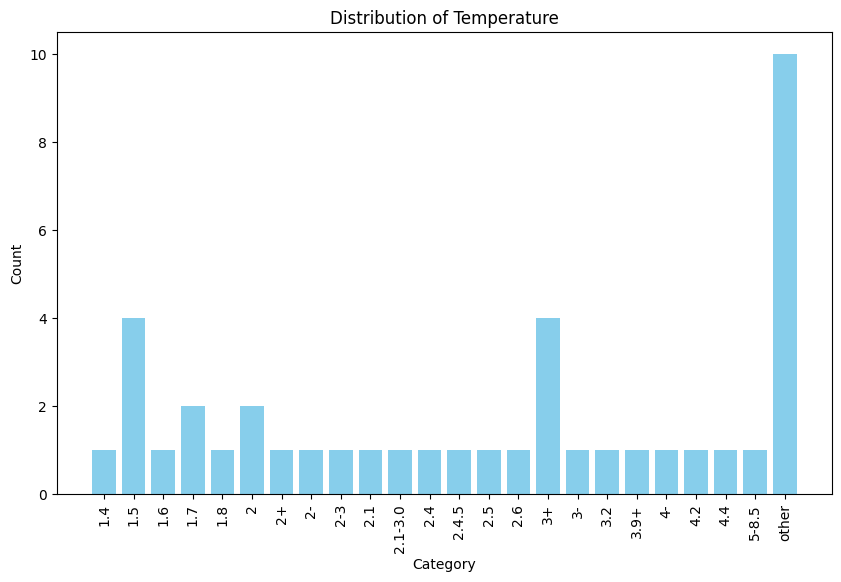

In [64]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt.csv')
#Question 5 - Scenario list 
question = results_final[results_final['question']=='q5']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
# Applying the function to the DataFrame column
question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(question['answer'] ) for item in sublist]
flattened_list

# Function to manually standardize items
def standardize_item(item):
    item = item.lower()
    if 'oc' in item:
        return item.replace('oc','')
    if item in ['3 or greater','>3','>3.0']:
        return '>3'
    else:
        return 'other'
    
mapping = {'+1.5':'1.5',
 '+1.7':'1.7',
 '+2.5':'2.5',
 '1.4':'1.4',
 '1.5':'1.5',
 '1.50':'1.5',
 '1.6':'1.6',
 '1.7':'1.7',
 '1.8':'1.8',
 '2':'2',
 '2-3':'2-3',
 '2-4.5':'2.4.5',
 '2.0':'2',
 '2.1':'2.1',
 '2.1-3.0':'2.1-3.0',
 '2.4':'2.4',
 '2.6':'2.6',
 '3 or greater':'3+',
 '3.0':'3+',
 '3.2':'3.2',
 '3.90+':'3.9+',
 '4.2':'4.2',
 '4.4':'4.4',
 '5-8.5':'5-8.5',
 '<1.5':'1.5',
 '<2':'2-',
 '<3':'3-',
 '<4':'4-',
 '>2':'2+',
 '>3':'3+',
 '>3.0':'3+',
 '[1.5':'1.5',
 'other':'other'} 

# Standardizing the list
standardized_list = dict()
for item in flattened_list:
    if isinstance(item, list):
        for sub_item in item:
            standardized_list[sub_item] = standardize_item(sub_item)
    else:
        standardized_list[item] = standardize_item(item)


# Counting occurrences of each category
standardized_df = pd.DataFrame([standardized_list]).T.reset_index()
standardized_df.columns =  columns=['original', 'code']
standardized_df['code'] = standardized_df['code'].map(mapping)
category_counts = standardized_df.groupby(['code']).count().reset_index()
category_counts.columns = ['Category','Count']
category_counts


# Sorting the categories alphabetically
sorted_df = category_counts.sort_values(by='Category').reset_index(drop=True)

# Drawing the bar chart
plt.figure(figsize=(10, 6))
plt.bar(sorted_df['Category'], sorted_df['Count'], color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Distribution of Temperature')
plt.xticks(rotation=90)

pd.DataFrame([standardized_list]).T.to_csv(folder + 'result/standardized_list_temperature.csv')

C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\3321230560.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


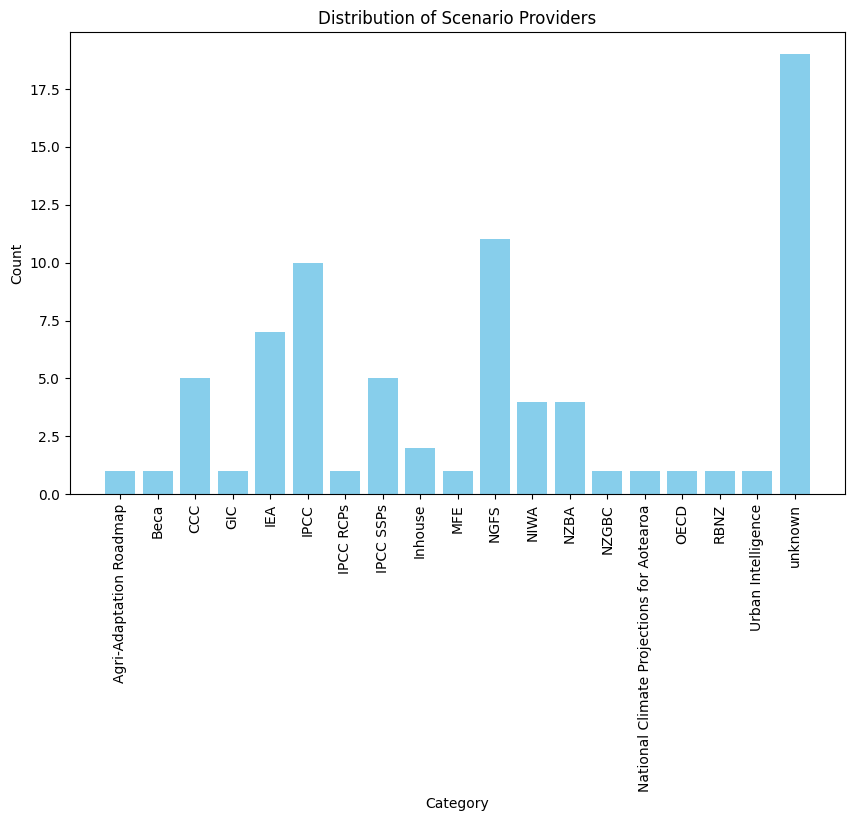

In [77]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt.csv')
#Question 5 - Scenario list 
question = results_final[results_final['question']=='q6']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
# Applying the function to the DataFrame column
question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(question['answer'] ) for item in sublist]
flattened_list

# Function to manually standardize items
def standardize_item(item):
    item = item.lower()
    if 'oc' in item:
        return item.replace('oc','')
    if item in ['3 or greater','>3','>3.0']:
        return '>3'
    else:
        return 'other'
    
mapping = {'IPCC':'IPCC',
 'NGFS':'NGFS',
 'NZBA':'NZBA',
 'National Climate Projections for Aotearoa':'National Climate Projections for Aotearoa',
 'Intergovernmental Panel on Climate Change (IPCC)':'IPCC',
 'Network for Greening the Financial System (NGFS)':'NGFS',
 'International Energy Agency (IEA)':'IEA',
 'Climate Change Commission (CCC)':'CCC',
 'OECD':'OECD',
 'IEA':'IEA',
 'NIWA':'NIWA',
 'CCC':'CCC',
 'Shared Socioeconomic Pathways (SSPs)':'IPCC SSPs',
 'Downscaled NZ climate change projections prepared by NIWA for Minister for the Environment (MfE)':'MFE',
 'Network for Greening the Financial System (NGFS) Climate Scenarios.':'NGFS',
 '':'unknown',
 'SSP1-1.9':'IPCC SSPs',
 'SSP2-4.5':'IPCC SSPs',
 'SSP3-7.0':'IPCC SSPs',
 'NZBA Report':'NZBA',
 'GIC Report':'GIC',
 'Climate Change Commission':'CCC',
 'The Agri-Adaptation Roadmap':'Agri-Adaptation Roadmap',
 'Urban Intelligence':'Urban Intelligence',
 'No temperature outcomes provided':'unknown',
 'There is no temperature outcome associated with this answer, so an empty list [] should be returned.':'unknown',
 'IPCC SSP':'IPCC SSPs',
 'RCP':'IPCC RCPs',
 'N/A':'unknown',
 'There is not enough information to create a list of temperature outcomes.':'unknown',
 '"I don\'t know."[I don\'t know.':'unknown',
 'New Zealand Green Building Council (NZGBC)':'NZGBC',
 'Beca Limited':'Beca',
 'Vista Group': 'Inhouse',
 'Unknown':'unknown',
 'Not used':'unknown',
 'Not commonly used':'unknown',
 'Bank of China':'Inhouse',
 '"NGFS':'NGFS',
 'IEA"':'IEA',
 'BNZ, New Zealand Banking Association, common set, climate scenario narratives, New Zealand banking sector, three scenario narratives, four chosen time horizons':'NZBA',
 'Niwa':'NIWA',
 "I don't know":'unknown',
 'RBNZ':'RBNZ'}

# Counting occurrences of each category
standardized_df = pd.DataFrame([flattened_list]).T
standardized_df.columns =  columns=[ 'original']
standardized_df['code'] = standardized_df['original'].map(mapping)
category_counts = standardized_df.groupby(['code']).count().reset_index()
category_counts.columns = ['Category','Count']
category_counts


# Sorting the categories alphabetically
sorted_df = category_counts.sort_values(by='Category').reset_index(drop=True)

# Drawing the bar chart
plt.figure(figsize=(10, 6))
plt.bar(sorted_df['Category'], sorted_df['Count'], color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Distribution of Scenario Providers')
plt.xticks(rotation=90)

pd.DataFrame([standardized_list]).T.to_csv(folder + 'result/standardized_list_dataproviders.csv')

C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\1673459557.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


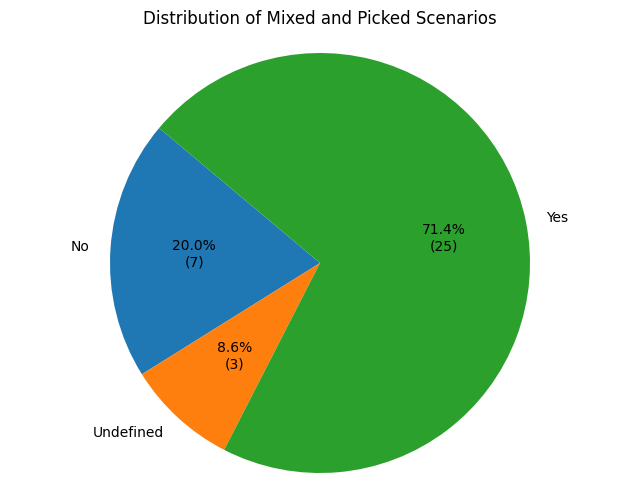

In [81]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt.csv')
question = results_final[results_final['question']=='q7']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
# Applying the function to the DataFrame column
question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(question['answer'] ) for item in sublist]
flattened_list


# Counting occurrences of each category
standardized_df = pd.DataFrame([flattened_list]).T
standardized_df.columns =  columns=[ 'original']
standardized_df['code'] = standardized_df['original']


# Group by the 'Category' column and count the number of lines
grouped_data = standardized_df.groupby('code').size()

# Function to format the labels with both count and percentage
def func(pct, allvals):
    absolute = int(pct/100.*sum(allvals))
    return f"{pct:.1f}%\n({absolute:d})"

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(grouped_data, labels=grouped_data.index, autopct=lambda pct: func(pct, grouped_data), 
         startangle=140)
plt.title('Distribution of Mixed and Picked Scenarios')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()



C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\1574284858.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


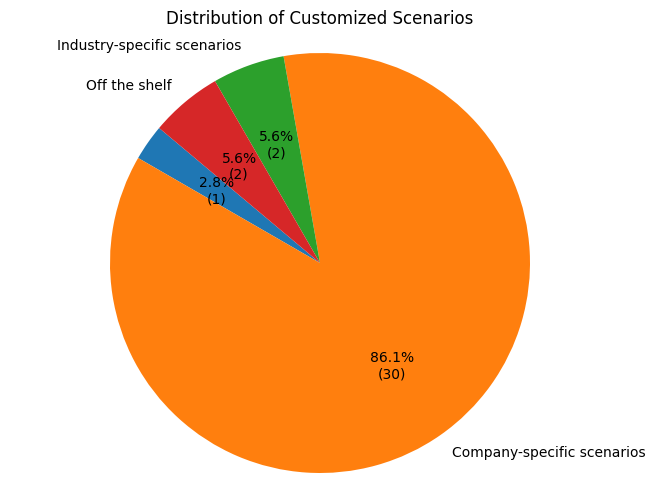

In [85]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt.csv')
question = results_final[results_final['question']=='q8']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
# Applying the function to the DataFrame column
question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(question['answer'] ) for item in sublist]
flattened_list


# Counting occurrences of each category
standardized_df = pd.DataFrame([flattened_list]).T
standardized_df.columns =  columns=[ 'original']
standardized_df['code'] = standardized_df['original'].fillna('Undefined')


# Group by the 'Category' column and count the number of lines
grouped_data = standardized_df.groupby('code').size()

# Function to format the labels with both count and percentage
def func(pct, allvals):
    absolute = int(pct/100.*sum(allvals))
    return f"{pct:.1f}%\n({absolute:d})"

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(grouped_data, labels=grouped_data.index, autopct=lambda pct: func(pct, grouped_data), 
         startangle=140)
plt.title('Distribution of Customized Scenarios')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()



C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\967000768.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


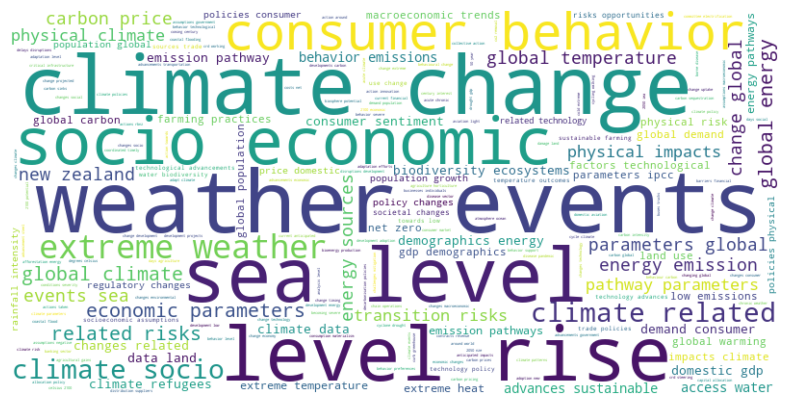

In [104]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt_q9_q15.csv')
question = results_final[results_final['question']=='q9']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
# Applying the function to the DataFrame column
question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(question['answer'] ) for item in sublist]
flattened_list


# Counting occurrences of each category
standardized_df = pd.DataFrame([flattened_list]).T
standardized_df.columns =  columns=[ 'original']
standardized_df['code'] = standardized_df['original'].str.replace('changes in','')
standardized_df = standardized_df[~standardized_df['code'].isin([' ', '', "I don't know"])]
standardized_df.to_csv(folder + 'result/standardized_list_variables.csv')

from sklearn.feature_extraction.text import CountVectorizer

# Extract text data
text_data = standardized_df['code'].str.cat(sep=' ')
# Remove stopwords
stop_words = set(stopwords.words('english'))
words = text_data.split()
filtered_text = ' '.join([word for word in words if word.lower() not in stop_words])

# Use CountVectorizer to find bigrams
vectorizer = CountVectorizer(ngram_range=(2, 2))
X = vectorizer.fit_transform([filtered_text])

# Sum up the counts of each bigram
bigram_counts = X.toarray().sum(axis=0)
bigram_features = vectorizer.get_feature_names_out()

# Create a dictionary of bigram and their counts
bigram_freq = dict(zip(bigram_features, bigram_counts))

# Select the top bigrams
top_bigrams = dict(Counter(bigram_freq).most_common())

# Create word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_bigrams)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\568041752.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


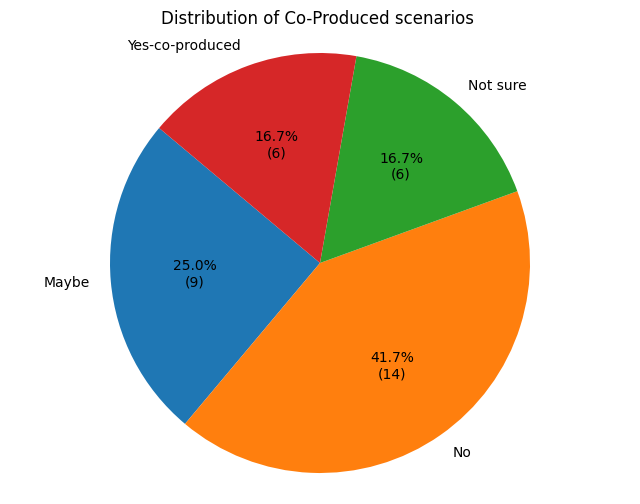

In [108]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt_q9_q15.csv')
question = results_final[results_final['question']=='q10']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
# Applying the function to the DataFrame column
question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(question['answer'] ) for item in sublist]
flattened_list


# Counting occurrences of each category
standardized_df = pd.DataFrame([flattened_list]).T
standardized_df.columns =  columns=[ 'original']
standardized_df['code'] = standardized_df['original'].str.replace('no','No')
standardized_df = standardized_df[~standardized_df['code'].isin([' ', '', "I don't know"])]
standardized_df


# Group by the 'Category' column and count the number of lines
grouped_data = standardized_df.groupby('code').size()

# Function to format the labels with both count and percentage
def func(pct, allvals):
    absolute = int(pct/100.*sum(allvals))
    return f"{pct:.1f}%\n({absolute:d})"

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(grouped_data, labels=grouped_data.index, autopct=lambda pct: func(pct, grouped_data), 
         startangle=140)
plt.title('Distribution of Co-Produced scenarios ')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\1770628282.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


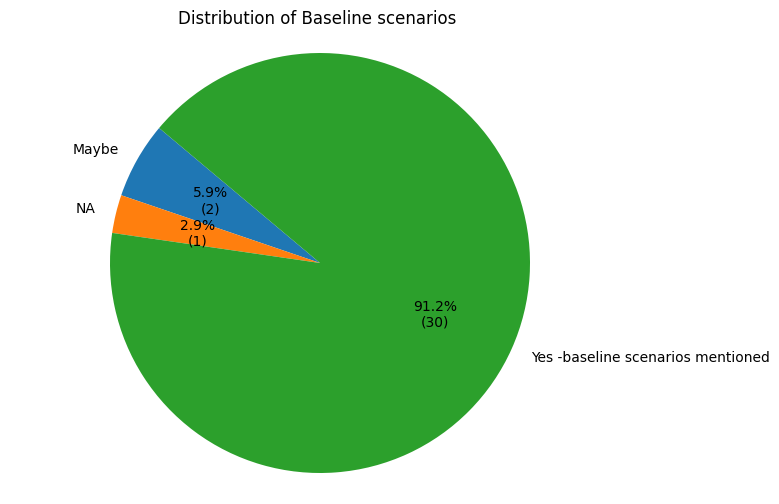

In [129]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt_q9_q15.csv')
question = results_final[results_final['question']=='q11']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
# Applying the function to the DataFrame column
question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(question['answer'] ) for item in sublist]
flattened_list

mapping = {'No-No baseline metioned':'No baseline metioned', 
            'Yes -baseline scenarios mentioned':'Yes -baseline scenarios mentioned',
            'Yes -baseline scenarios mentioned/No-No baseline metioned':'NA',
           'Yes -baseline variables mentioned/Maybe/No-No baseline metioned/Not sure quote, No special characters, No . with "':'NA',
             '" as delimiter.Yes -baseline scenarios mentioned/Yes -baseline variables mentioned':'NA',
            'Yes -baseline scenarios mentioned/Yes -baseline variables mentioned':'Yes -baseline scenarios mentioned',
           'Maybe':'Maybe',
            'Yes -baseline variables mentioned':'Yes -baseline scenarios mentioned',
            'Not sure quote, No special characters, No':'No baseline metioned', 
            'Yes-baseline scenarios mentioned':'Yes -baseline scenarios mentioned'
          }

# Counting occurrences of each category
standardized_df = pd.DataFrame([flattened_list]).T
standardized_df.columns = [ 'original']
standardized_df['code'] = standardized_df['original'].map(mapping)
standardized_df = standardized_df[~standardized_df['code'].isin([' ', '', "I don't know"])]
standardized_df

# Group by the 'Category' column and count the number of lines
grouped_data = standardized_df.groupby('code').size()

# Function to format the labels with both count and percentage
def func(pct, allvals):
    absolute = int(pct/100.*sum(allvals))
    return f"{pct:.1f}%\n({absolute:d})"

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(grouped_data, labels=grouped_data.index, autopct=lambda pct: func(pct, grouped_data), 
         startangle=140)
plt.title('Distribution of Baseline scenarios ')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\1405282491.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


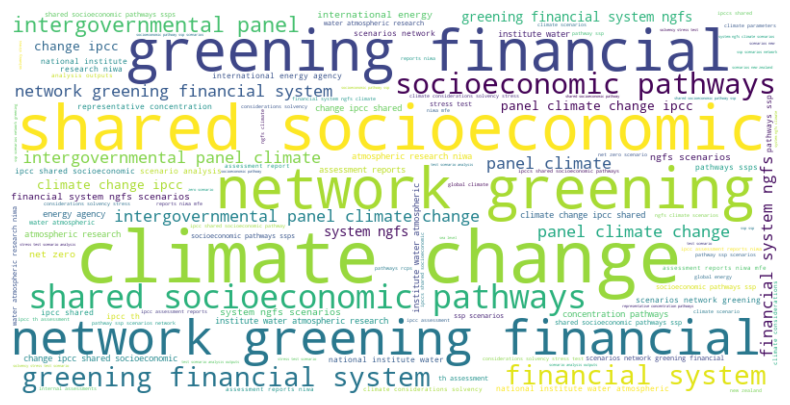

In [140]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt_q9_q15.csv')
question = results_final[results_final['question']=='q12']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(',')]
        return cleaned_list
# Applying the function to the DataFrame column
question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(question['answer'] ) for item in sublist]
flattened_list

# Counting occurrences of each category
standardized_df = pd.DataFrame([flattened_list]).T
standardized_df.columns = [ 'original']
standardized_df['code'] = standardized_df['original']
standardized_df = standardized_df[~standardized_df['code'].isin([' ', '', "I don't know"])]

standardized_df.to_csv(folder + 'result/standardized_list_models.csv')

from sklearn.feature_extraction.text import CountVectorizer

# Extract text data
text_data = standardized_df['code'].str.cat(sep=' ')
# Remove special characters
text_data_cleaned = re.sub(r'[^A-Za-z\s]', '', text_data)
# Remove stopwords
stop_words = set(stopwords.words('english'))
words = text_data_cleaned.split()
filtered_text = ' '.join([word for word in words if word.lower() not in stop_words])
filtered_text

# Use CountVectorizer to find bigrams
vectorizer = CountVectorizer(ngram_range=(2, 4))  # Adjusted to include bigrams, trigrams, and quagrams
X = vectorizer.fit_transform([filtered_text])

# Sum up the counts of each bigram
bigram_counts = X.toarray().sum(axis=0)
bigram_features = vectorizer.get_feature_names_out()

# Create a dictionary of bigram and their counts
bigram_freq = dict(zip(bigram_features, bigram_counts))

# Select the top bigrams
top_bigrams = dict(Counter(bigram_freq).most_common())

# Create word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_bigrams)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\3448368231.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


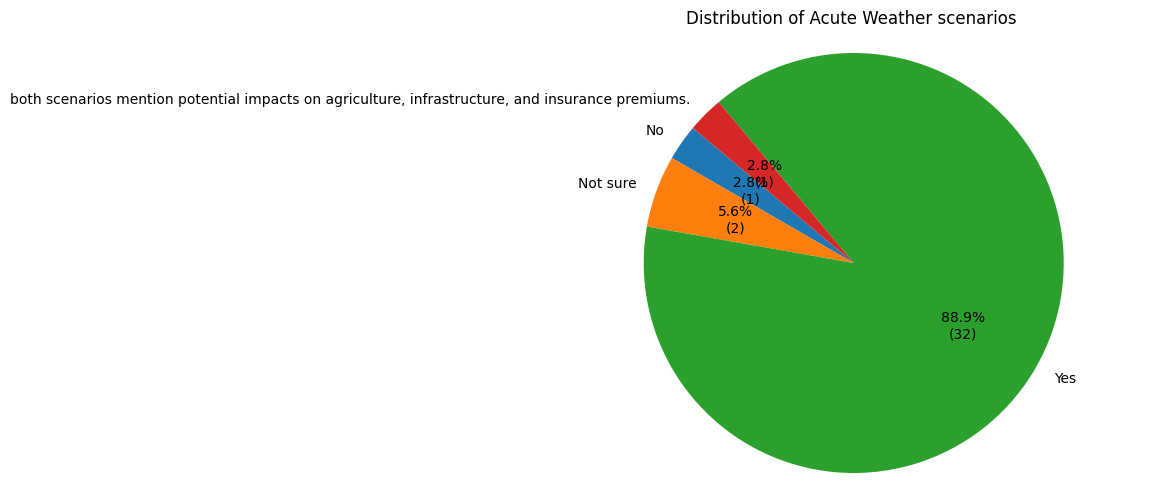

In [147]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt_q9_q15.csv')
question = results_final[results_final['question']=='q13']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
# Applying the function to the DataFrame column
question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(question['answer'] ) for item in sublist]
flattened_list

# Counting occurrences of each category
standardized_df = pd.DataFrame([flattened_list]).T
standardized_df.columns = [ 'original']
standardized_df['code'] = standardized_df['original']
standardized_df = standardized_df[~standardized_df['code'].isin([' ', '', "I don't know"])]

# Group by the 'Category' column and count the number of lines
grouped_data = standardized_df.groupby('code').size()

# Function to format the labels with both count and percentage
def func(pct, allvals):
    absolute = int(pct/100.*sum(allvals))
    return f"{pct:.1f}%\n({absolute:d})"

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(grouped_data, labels=grouped_data.index, autopct=lambda pct: func(pct, grouped_data), 
         startangle=140)
plt.title('Distribution of Acute Weather scenarios ')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\347892628.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


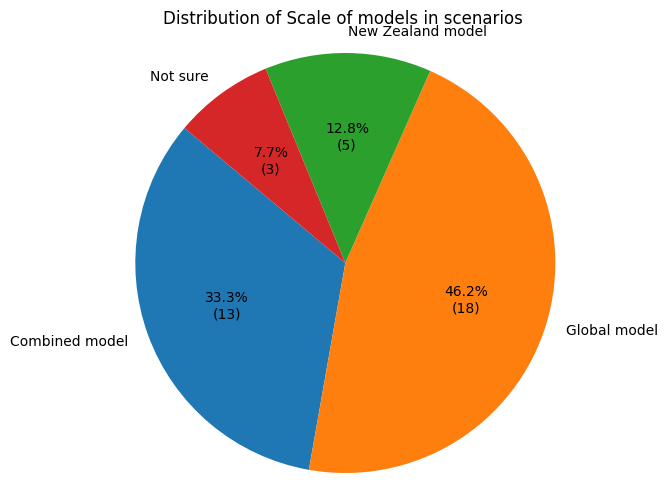

In [149]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt_q9_q15.csv')
question = results_final[results_final['question']=='q14']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
# Applying the function to the DataFrame column
question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(question['answer'] ) for item in sublist]
flattened_list

# Counting occurrences of each category
standardized_df = pd.DataFrame([flattened_list]).T
standardized_df.columns = [ 'original']
standardized_df['code'] = standardized_df['original']
standardized_df = standardized_df[~standardized_df['code'].isin([' ', '', "I don't know"])]

# Group by the 'Category' column and count the number of lines
grouped_data = standardized_df.groupby('code').size()

# Function to format the labels with both count and percentage
def func(pct, allvals):
    absolute = int(pct/100.*sum(allvals))
    return f"{pct:.1f}%\n({absolute:d})"

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(grouped_data, labels=grouped_data.index, autopct=lambda pct: func(pct, grouped_data), 
         startangle=140)
plt.title('Distribution of Scale of models in scenarios ')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [158]:
results_final =pd.read_csv(folder + 'result/question_coded_chatgpt_q9_q15.csv')
question = results_final[results_final['question']=='q15']
# Function to clean and evaluate each string in the DataFrame column
def clean_and_evaluate_list(s):
    # Handle single quotes correctly
    s = str(s).replace("\\'", "'")
    
    # Check if the string is formatted as a numbered list
    if s.strip().startswith('1.'):
        # Split the string into parts based on the pattern
        parts = s.split('\n')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
    else:
        # Otherwise, assume it is a valid list in string format and evaluate it directly
        s = s.replace('\\"', '"')
        #s = s.replace(';"', ',')
        cleaned_list = [item.strip() for item in s.strip('[]').split(';')]
        return cleaned_list
# Applying the function to the DataFrame column
question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)
# Flattening the list of lists
flattened_list = [item for sublist in list(question['answer'] ) for item in sublist]
# Remove special characters
flattened_list = [re.sub(r'[^A-Za-z0-9\s,-:]', '',item) for item in flattened_list]
flattened_list = [item.replace('short term: ','').\
                  replace('long term: ','').\
                  replace('medium term: ','')
                  for item in flattened_list]
flattened_list
mapping ={'2030, 2050, 2100',
 '0-5 years, 5-10 years, 10-30 years',
 '2025, 2030, 2050',
 '3-7 year period, aligned with the banks strategy review and risk appetite review, 8-27 year period, aligned with the time scale for climate change, NZBA Climate scenarios, and New Zealand legislation, including the Zero Carbon Act, 28-50 year period, aligned with the time scale for climate change, NZBA Climate scenarios, and New Zealand legislation, including the Zero Carbon Act',
 '2023, 2024, future',
 '2024-2030 5-6 years, 2031-2040 15 years, 2041-2050 25 years',
 '3 years, 10 years, 30 years',
 '2024-2028, 2029-2035, 2036-2050',
 'strategic planning horizon and capital deployment plans, Sustainability Strategy, impact on the environment, social impact, and governance',
 '2025, 2035, 2050',
 '0-3 years, 3-8 years, 8 years',
 'now-2030, 2030-2050, 2050-2100',
 'next few years, next few decades, second half of the century',
 '2030, 2050, 2100',
 '1-5 years, 6-10 years, 10 years',
 '2023-2030, 2031-2050, 2051-onwards',
 '2023 to 2030, 2031 to 2050, 2051 onwards',
 'N/A, N/A, N/A',
 '1-6 years, 2031-2050, 2051-2100',
 '2023-2028, 2029-2039, 2040-2050',
 '2030, 2050, 2080',
 'now until 2030, 2030 to 2050, 2050 to 2100',
 'one to three years, three to 10 years,  10 years',
 '3 years, 10 years, 30 years',
 '2024-2025, 2025-2030, 2030-2050',
 '1-3 years, 5-10 years, 30 years',
 '2030, 2050, 2080',
 '2025, 2035, 2050',
 '3 years, 10 years, 30 years',
 '2030, 2040, 2050',
 'next financial year, 2026-2030, 2031-2050',
 '2030, 2050, 2080-2100',
 '2023, 2050, beyond 2050',
 '1-3 years, 3-10 years, 10-30 years',
 '1-2 years',
 '3-7 years',
 '8-27 years'}

C:\Users\QuyenN\AppData\Local\Temp\ipykernel_13864\3675217360.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  question['answer'] = question['answer'].str.replace('\n','').apply(clean_and_evaluate_list)


['2030, 2050, 2100',
 '0-5 years, 5-10 years, 10-30 years',
 '2025, 2030, 2050',
 '3-7 year period, aligned with the banks strategy review and risk appetite review, 8-27 year period, aligned with the time scale for climate change, NZBA Climate scenarios, and New Zealand legislation, including the Zero Carbon Act, 28-50 year period, aligned with the time scale for climate change, NZBA Climate scenarios, and New Zealand legislation, including the Zero Carbon Act',
 '2023, 2024, future',
 '2024-2030 5-6 years, 2031-2040 15 years, 2041-2050 25 years',
 '3 years, 10 years, 30 years',
 '2024-2028, 2029-2035, 2036-2050',
 'strategic planning horizon and capital deployment plans, Sustainability Strategy, impact on the environment, social impact, and governance',
 '2025, 2035, 2050',
 '0-3 years, 3-8 years, 8 years',
 'now-2030, 2030-2050, 2050-2100',
 'next few years, next few decades, second half of the century',
 '2030, 2050, 2100',
 '1-5 years, 6-10 years, 10 years',
 '2023-2030, 2031-2050,